# Weather Source Comparison: Copernicus vs Keskkonnaportaal

**Goal:** Validate whether **Copernicus ERA5-Land** reanalysis can substitute for **keskkonnaportaal (Tallinn-Harku)** station data when building Energy Signature (ES) baselines.

**Method:** Smertinas-inspired frequentist three-tier ES approach (OLS/ARIMA, not Bayesian):
1. **ES v1** — Baseline (temp + wind, no solar initially for fair comparison)
2. **ARX-ES** — Add AR(1) lag (thermal inertia approximation)
3. **ARMAX-ES** — Add MA(3) terms (residual autocorrelation)

**Important:** KKP has `sunshine_duration_min` (crude proxy), while COP has `ssrd` (global solar irradiance in W/m²). These are **dimensionally incompatible**, so we compare temp+wind only first, then test solar separately.

**Building:** U06 (Teaching building 6), 2022–2024

**Reference:** Smertinas et al., *Estimation of Building Energy Demand Characteristics using Bayesian Statistics and Energy Signature Models* (2025).

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.stattools import acf
import warnings
import sys

# Add utils to path
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from utils.building_data_loader import get_building_dataframe

# Note: warnings are NOT globally suppressed — model convergence issues are surfaced

---
## Configuration

In [2]:
BUILDING_CODE = "U06"
WEATHER_FILE = PROJECT_ROOT / "data" / "combined_weather_2022_2025.csv"

# Heat meters for U06 (sum all 6 for total building heat)
HEAT_METERS = [f"bhb{i:02d}" for i in range(1, 7)]
HEAT_COLS = [f"{m}_measurement_delta_mwh" for m in HEAT_METERS]

print(f"Building: {BUILDING_CODE}")
print(f"Heat meters: {HEAT_METERS}")
print(f"Weather file: {WEATHER_FILE}")

Building: U06
Heat meters: ['bhb01', 'bhb02', 'bhb03', 'bhb04', 'bhb05', 'bhb06']
Weather file: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/combined_weather_2022_2025.csv


---
## Important Note: Solar Variable Incompatibility

**Problem:** KKP and COP have different solar measurements:
- **KKP**: `sunshine_duration_min` — minutes of sunshine per hour (0-60 min)
- **COP**: `ssrd` — Surface Solar Radiation Downwards in W/m² (global irradiance)

**Smertinas uses:** Global solar irradiance (W/m²), same as COP.

**These are dimensionally incompatible** and cannot be directly compared in the same model.

**Solution:**
1. **Fair comparison (ES v1a)**: Temp + wind only (no solar) for both KKP and COP
2. **Solar benefit (ES v1b)**: Add solar irradiance to COP model to show improvement
3. **Validation**: If temp+wind R² matches, weather sources are equivalent for ES baseline

This approach validates that COP provides comparable weather data while demonstrating the value of proper solar irradiance.

---
## Load Data

### 1. Load heat + KKP weather (via building_data_loader)
### 2. Load heat + COP weather (merge with combined_weather file)

In [3]:
# Load U06 with KKP weather (default from loader)
u06_kkp = get_building_dataframe(BUILDING_CODE, include_weather=True)
print(f"U06 + KKP: {u06_kkp.shape}")
print(f"Date range: {u06_kkp['datetime'].min()} to {u06_kkp['datetime'].max()}")
u06_kkp.head()

U06 + KKP: (26275, 36)
Date range: 2022-01-01 00:00:00 to 2024-12-30 18:00:00


,datetime,indoor_temp_constant_c,bhb01_measurement_cumulative_mwh,bhb01_supply_flow_temp_c,bhb01_return_flow_temp_c,bhb01_measurement_delta_mwh,bhb02_measurement_cumulative_mwh,bhb02_supply_flow_temp_c,bhb02_return_flow_temp_c,bhb02_measurement_delta_mwh,...,air_pressure_hpa,precipitation_mm,relative_humidity_pct,sunshine_duration_min,air_temp_c,air_temp_min_c,air_temp_max_c,wind_direction_deg,wind_speed_ms,wind_gust_max_ms
0,2022-01-01 00:00:00,21,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1001.6,0.3,99.0,0.0,0.0,-0.8,0.0,85.0,1.4,2.0
1,2022-01-01 01:00:00,21,11306.010000,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,...,1002.0,0.4,100.0,0.0,-0.1,-0.1,0.1,45.0,1.0,2.5
2,2022-01-01 02:00:00,21,11306.180000,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,...,1002.4,0.5,100.0,0.0,-0.1,-0.2,-0.1,32.0,1.5,2.7
3,2022-01-01 03:00:00,21,11306.420000,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,...,1003.0,0.3,100.0,0.0,-0.3,-0.3,-0.1,29.0,1.9,3.3
4,2022-01-01 04:00:00,21,11306.623333,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,...,1004.1,0.2,99.0,0.0,-0.4,-0.4,-0.2,17.0,1.3,3.2


In [4]:
# Load U06 heat only, merge with COP weather
u06_heat = get_building_dataframe(BUILDING_CODE, include_weather=False)
weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"], index_col="datetime")
cop_cols = [c for c in weather.columns if c.startswith("COP_")]
weather_cop = weather[cop_cols]
u06_cop = u06_heat.merge(weather_cop, left_on="datetime", right_index=True, how="left")
print(f"U06 + COP: {u06_cop.shape}")
print(f"COP columns: {cop_cols}")
u06_cop.head()

U06 + COP: (27115, 29)
COP columns: ['COP_temp_c', 'COP_wind_speed_ms', 'COP_ssrd_W_per_m2']


,datetime,indoor_temp_constant_c,bhb01_measurement_cumulative_mwh,bhb01_supply_flow_temp_c,bhb01_return_flow_temp_c,bhb01_measurement_delta_mwh,bhb02_measurement_cumulative_mwh,bhb02_supply_flow_temp_c,bhb02_return_flow_temp_c,bhb02_measurement_delta_mwh,...,bhb05_supply_flow_temp_c,bhb05_return_flow_temp_c,bhb05_measurement_delta_mwh,bhb06_measurement_cumulative_mwh,bhb06_supply_flow_temp_c,bhb06_return_flow_temp_c,bhb06_measurement_delta_mwh,COP_temp_c,COP_wind_speed_ms,COP_ssrd_W_per_m2
0,2022-01-01 00:00:00,21,11305.785000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.147308,0.602060,NaN
1,2022-01-01 01:00:00,21,11306.010000,NaN,NaN,0.225000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.441498,1.423145,0.0
2,2022-01-01 02:00:00,21,11306.180000,NaN,NaN,0.170000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.059174,2.314176,0.0
3,2022-01-01 03:00:00,21,11306.420000,NaN,NaN,0.240000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.089447,2.695371,0.0
4,2022-01-01 04:00:00,21,11306.623333,NaN,NaN,0.203333,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.583832,3.038822,0.0


In [5]:
# ── Data Quality Guards ──
# 1. Check for duplicate timestamps
dup_kkp = u06_kkp["datetime"].duplicated().sum()
dup_cop = u06_cop["datetime"].duplicated().sum()
print(f"Duplicate timestamps: KKP={dup_kkp}, COP={dup_cop}")
if dup_kkp > 0:
    u06_kkp = u06_kkp.drop_duplicates(subset="datetime", keep="first")
    print(f"  → KKP deduplicated: {u06_kkp.shape}")
if dup_cop > 0:
    u06_cop = u06_cop.drop_duplicates(subset="datetime", keep="first")
    print(f"  → COP deduplicated: {u06_cop.shape}")

# 2. Check weather combined file for duplicate datetimes
weather_dups = weather.index.duplicated().sum()
print(f"Combined weather file duplicate datetimes: {weather_dups}")
if weather_dups > 0:
    weather = weather[~weather.index.duplicated(keep="first")]
    print(f"  → Weather deduplicated: {weather.shape}")

# 3. Missingness by variable
print(f"\nMissingness in hourly data (n={len(u06_cop)} hours):")
for col, name in [("COP_temp_c", "COP temp"), ("COP_wind_speed_ms", "COP wind"),
                   ("COP_ssrd_W_per_m2", "COP solar"), ("air_temp_c", "KKP temp"),
                   ("wind_speed_ms", "KKP wind"), ("sunshine_duration_min", "KKP sun")]:
    source = u06_kkp if col.startswith(("air", "wind", "sun")) else u06_cop
    if col in source.columns:
        n_miss = source[col].isna().sum()
        pct = n_miss / len(source) * 100
        print(f"  {name:15s}: {n_miss:5d} missing ({pct:.1f}%)")

# 4. Heat data missingness
heat_miss = u06_heat[HEAT_COLS].isna().any(axis=1).sum()
print(f"\n  Heat meters:     {heat_miss:5d} hours with any NaN ({heat_miss/len(u06_heat)*100:.1f}%)")
print("\nData quality checks passed ✓")

Duplicate timestamps: KKP=0, COP=840
  → COP deduplicated: (26275, 29)
Combined weather file duplicate datetimes: 1128
  → Weather deduplicated: (35088, 6)

Missingness in hourly data (n=26275 hours):
  COP temp       :   390 missing (1.5%)
  COP wind       :   390 missing (1.5%)
  COP solar      :   688 missing (2.6%)
  KKP temp       :     0 missing (0.0%)
  KKP wind       :    41 missing (0.2%)
  KKP sun        :     0 missing (0.0%)

  Heat meters:     14605 hours with any NaN (55.6%)

Data quality checks passed ✓


---
## Daily Aggregation (Smertinas-inspired)

Following Smertinas et al.'s approach:
- **Heat (Φ)** → sum (kWh/day)
- **T_out** → daily mean (°C)
- **Wind** → daily mean (m/s)
- **Solar** → daily mean (KKP has minutes, COP has W/m²)

**Critical design**: Heat is aggregated **once** from heat-only data, then weather features are joined separately. This ensures KKP and COP models predict the **identical** daily heat target. Weather availability (e.g. COP solar NaN) must **not** affect which hours contribute to heat or which days are included in temp+wind-only models.

In [6]:
# ── Step 1: Aggregate heat ONCE from heat-only data ──
u06_heat["Phi_kWh"] = u06_heat[HEAT_COLS].sum(axis=1) * 1e3  # MWh → kWh
hourly_heat = u06_heat[["datetime", "Phi_kWh"]].dropna()
hourly_heat["date"] = hourly_heat["datetime"].dt.date
daily_heat = hourly_heat.groupby("date", as_index=False).agg(Phi_kWh=("Phi_kWh", "sum"))
daily_heat = daily_heat[daily_heat["Phi_kWh"] > 0]
daily_heat["datetime"] = pd.to_datetime(daily_heat["date"])
print(f"Daily heat (source-independent): {len(daily_heat)} days")
print(f"Phi range: {daily_heat['Phi_kWh'].min():.0f} – {daily_heat['Phi_kWh'].max():.0f} kWh/day")

# ── Step 2: Aggregate KKP weather separately ──
# temp+wind (for fair comparison, no sunshine requirement)
kkp_tw = u06_kkp[["datetime", "air_temp_c", "wind_speed_ms"]].dropna()
kkp_tw["date"] = kkp_tw["datetime"].dt.date
daily_kkp_tw = kkp_tw.groupby("date", as_index=False).agg(
    T_out_c=("air_temp_c", "mean"), wind_ms=("wind_speed_ms", "mean"))

# sunshine (for KKP solar reference, separate availability)
kkp_sun = u06_kkp[["datetime", "sunshine_duration_min"]].dropna()
kkp_sun["date"] = kkp_sun["datetime"].dt.date
daily_kkp_sun = kkp_sun.groupby("date", as_index=False).agg(sun_min=("sunshine_duration_min", "sum"))

# ── Step 3: Aggregate COP weather separately ──
# temp+wind (NO ssrd requirement — critical fix)
cop_tw = u06_cop[["datetime", "COP_temp_c", "COP_wind_speed_ms"]].dropna()
cop_tw["date"] = cop_tw["datetime"].dt.date
daily_cop_tw = cop_tw.groupby("date", as_index=False).agg(
    T_out_c=("COP_temp_c", "mean"), wind_ms=("COP_wind_speed_ms", "mean"))

# solar irradiance (separate availability, for solar tiers only)
cop_solar = u06_cop[["datetime", "COP_ssrd_W_per_m2"]].dropna()
cop_solar["date"] = cop_solar["datetime"].dt.date
daily_cop_solar = cop_solar.groupby("date", as_index=False).agg(
    solar_W_per_m2=("COP_ssrd_W_per_m2", "mean"))

# ── Step 4: Join on common dates (identical y for both sources) ──
common_dates_tw = (set(daily_heat["date"])
                   & set(daily_kkp_tw["date"])
                   & set(daily_cop_tw["date"]))
common_dates_tw = sorted(common_dates_tw)

daily = daily_heat[daily_heat["date"].isin(common_dates_tw)].copy().reset_index(drop=True)
daily = daily.merge(daily_kkp_tw, on="date", suffixes=("", "_kkp")).rename(
    columns={"T_out_c": "kkp_T", "wind_ms": "kkp_wind"})
daily = daily.merge(daily_cop_tw, on="date").rename(
    columns={"T_out_c": "cop_T", "wind_ms": "cop_wind"})
# Add solar where available (left join — NaN where solar missing)
daily = daily.merge(daily_cop_solar, on="date", how="left")
daily = daily.merge(daily_kkp_sun, on="date", how="left")

print(f"\nCommon days (heat + KKP tw + COP tw): {len(daily)}")
print(f"  of which have COP solar: {daily['solar_W_per_m2'].notna().sum()}")
print(f"  of which have KKP sunshine: {daily['sun_min'].notna().sum()}")
print(f"Phi is IDENTICAL for KKP and COP ✓")
daily.head()

Daily heat (source-independent): 1007 days
Phi range: 0 – 17090 kWh/day

Common days (heat + KKP tw + COP tw): 1007
  of which have COP solar: 1007
  of which have KKP sunshine: 1007
Phi is IDENTICAL for KKP and COP ✓


,date,Phi_kWh,datetime,kkp_T,kkp_wind,cop_T,cop_wind,solar_W_per_m2,sun_min
0,2022-01-01,4908.333333,2022-01-01,-3.650000,2.387500,-4.601329,3.383781,14.055157,204.0
1,2022-01-02,5696.666667,2022-01-02,-5.225000,3.891667,-5.836395,3.891211,4.763976,0.0
2,2022-01-03,5763.333333,2022-01-03,-1.358333,2.116667,-0.813792,2.413356,3.829140,0.0
3,2022-01-04,4653.333333,2022-01-04,0.858333,2.637500,0.714427,3.406973,4.376021,2.0
4,2022-01-05,4920.000000,2022-01-05,-0.241667,2.195833,-1.866323,2.309482,13.868611,0.0


In [7]:
# ── Verification: data integrity checks ──
# 1. No duplicate dates
assert daily["date"].is_unique, "Duplicate dates in daily!"

# 2. Both sources have same Phi (by construction)
print("✓ Phi_kWh is identical for KKP and COP (aggregated from heat-only data)")

# 3. Weather coverage summary
print(f"\n=== Daily dataset summary ===")
print(f"Total days: {len(daily)}")
print(f"Date range: {daily['datetime'].min().date()} to {daily['datetime'].max().date()}")
print(f"Phi range:  {daily['Phi_kWh'].min():.0f} – {daily['Phi_kWh'].max():.0f} kWh/day")
print(f"\nWeather coverage:")
print(f"  KKP temp:  {daily['kkp_T'].notna().sum()} / {len(daily)} days")
print(f"  KKP wind:  {daily['kkp_wind'].notna().sum()} / {len(daily)} days")
print(f"  COP temp:  {daily['cop_T'].notna().sum()} / {len(daily)} days")
print(f"  COP wind:  {daily['cop_wind'].notna().sum()} / {len(daily)} days")
print(f"  COP solar: {daily['solar_W_per_m2'].notna().sum()} / {len(daily)} days")
print(f"  KKP sun:   {daily['sun_min'].notna().sum()} / {len(daily)} days")

# 4. Temperature comparison
print(f"\nTemp comparison (KKP vs COP):")
print(f"  Correlation: {daily['kkp_T'].corr(daily['cop_T']):.4f}")
print(f"  Mean bias (COP−KKP): {(daily['cop_T'] - daily['kkp_T']).mean():.2f} °C")
print(f"Wind comparison:")
print(f"  Correlation: {daily['kkp_wind'].corr(daily['cop_wind']):.4f}")
print(f"  Mean bias (COP−KKP): {(daily['cop_wind'] - daily['kkp_wind']).mean():.2f} m/s")

✓ Phi_kWh is identical for KKP and COP (aggregated from heat-only data)

=== Daily dataset summary ===
Total days: 1007
Date range: 2022-01-01 to 2024-12-30
Phi range:  0 – 17090 kWh/day

Weather coverage:
  KKP temp:  1007 / 1007 days
  KKP wind:  1007 / 1007 days
  COP temp:  1007 / 1007 days
  COP wind:  1007 / 1007 days
  COP solar: 1007 / 1007 days
  KKP sun:   1007 / 1007 days

Temp comparison (KKP vs COP):
  Correlation: 0.9962
  Mean bias (COP−KKP): -0.08 °C
Wind comparison:
  Correlation: 0.9152
  Mean bias (COP−KKP): 0.46 m/s


---
## Weather Comparison: COP vs KKP

Check for systematic biases in temp and wind before fitting ES models.

Weather comparison (n=1007 common days):
Temperature: corr=0.996, bias(COP−KKP)=-0.08 °C, RMSE=0.77 °C
Wind speed:  corr=0.915, bias(COP−KKP)=0.46 m/s, RMSE=0.71 m/s


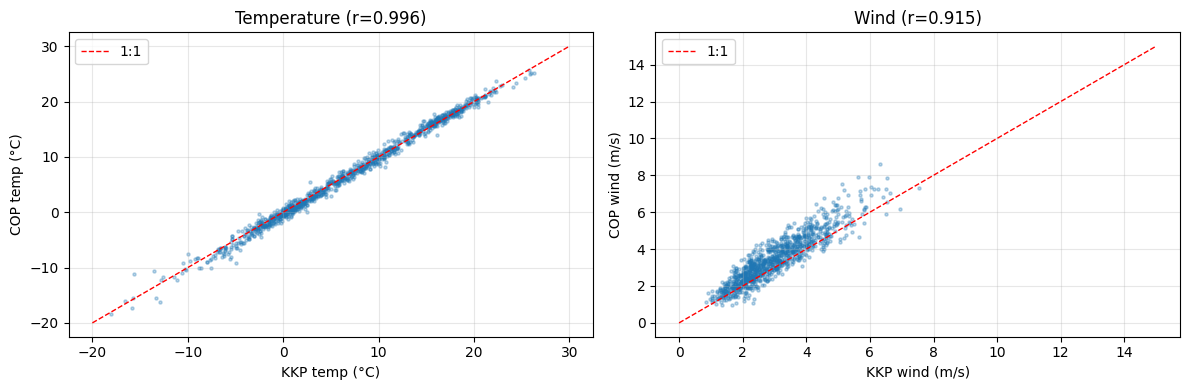

In [8]:
# Weather comparison (already on common dates from unified daily DataFrame)
print(f"Weather comparison (n={len(daily)} common days):")
print(f"Temperature: corr={daily['kkp_T'].corr(daily['cop_T']):.3f}, "
      f"bias(COP−KKP)={daily['cop_T'].mean() - daily['kkp_T'].mean():.2f} °C, "
      f"RMSE={np.sqrt(mean_squared_error(daily['kkp_T'], daily['cop_T'])):.2f} °C")
print(f"Wind speed:  corr={daily['kkp_wind'].corr(daily['cop_wind']):.3f}, "
      f"bias(COP−KKP)={daily['cop_wind'].mean() - daily['kkp_wind'].mean():.2f} m/s, "
      f"RMSE={np.sqrt(mean_squared_error(daily['kkp_wind'], daily['cop_wind'])):.2f} m/s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.scatter(daily["kkp_T"], daily["cop_T"], alpha=0.3, s=5)
ax1.plot([-20, 30], [-20, 30], "r--", lw=1, label="1:1")
ax1.set_xlabel("KKP temp (°C)"); ax1.set_ylabel("COP temp (°C)")
ax1.set_title(f"Temperature (r={daily['kkp_T'].corr(daily['cop_T']):.3f})")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.scatter(daily["kkp_wind"], daily["cop_wind"], alpha=0.3, s=5)
ax2.plot([0, 15], [0, 15], "r--", lw=1, label="1:1")
ax2.set_xlabel("KKP wind (m/s)"); ax2.set_ylabel("COP wind (m/s)")
ax2.set_title(f"Wind (r={daily['kkp_wind'].corr(daily['cop_wind']):.3f})")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# ES Model Fitting: Three Tiers

## Tier 1a: ES v1 — Temp + Wind Only (Fair Comparison)

$$
\Phi(t) = UA \cdot (T_{base} - T_{out}(t)) + \beta_{wind} \cdot W(t) + \Phi_{base}
$$

**No solar term** — this allows fair comparison between KKP and COP.

Simplification: Fix T_base = 15°C, fit as linear regression.

In [9]:
# ── ES v1a: Both sources, temp + wind only, IDENTICAL y ──
T_base = 15.0
y = daily["Phi_kWh"]  # Same target for both sources

# KKP
daily["kkp_dT"] = T_base - daily["kkp_T"]
X_kkp_v1a = daily[["kkp_dT", "kkp_wind"]]
lm_kkp_v1a = LinearRegression().fit(X_kkp_v1a, y)
daily["pred_kkp_v1a"] = lm_kkp_v1a.predict(X_kkp_v1a)
r2_kkp_v1a = r2_score(y, daily["pred_kkp_v1a"])
rmse_kkp_v1a = np.sqrt(mean_squared_error(y, daily["pred_kkp_v1a"]))
UA_kkp_v1a, beta_wind_kkp_v1a = lm_kkp_v1a.coef_
Phi_base_kkp_v1a = lm_kkp_v1a.intercept_

# COP
daily["cop_dT"] = T_base - daily["cop_T"]
X_cop_v1a = daily[["cop_dT", "cop_wind"]]
lm_cop_v1a = LinearRegression().fit(X_cop_v1a, y)
daily["pred_cop_v1a"] = lm_cop_v1a.predict(X_cop_v1a)
r2_cop_v1a = r2_score(y, daily["pred_cop_v1a"])
rmse_cop_v1a = np.sqrt(mean_squared_error(y, daily["pred_cop_v1a"]))
UA_cop_v1a, beta_wind_cop_v1a = lm_cop_v1a.coef_
Phi_base_cop_v1a = lm_cop_v1a.intercept_

print(f"=== ES v1a (temp+wind, same y, n={len(daily)} days) ===")
print(f"{'':12s} {'UA':>10s} {'β_wind':>10s} {'Φ_base':>10s} {'R²':>8s} {'RMSE':>8s}")
print(f"{'KKP':12s} {UA_kkp_v1a:10.2f} {beta_wind_kkp_v1a:10.2f} {Phi_base_kkp_v1a:10.1f} {r2_kkp_v1a:8.4f} {rmse_kkp_v1a:8.0f}")
print(f"{'COP':12s} {UA_cop_v1a:10.2f} {beta_wind_cop_v1a:10.2f} {Phi_base_cop_v1a:10.1f} {r2_cop_v1a:8.4f} {rmse_cop_v1a:8.0f}")
print(f"{'ΔR²':12s} {r2_cop_v1a - r2_kkp_v1a:+.4f}")
print(f"\nUnits: UA = kWh/day/K, β_wind = kWh/day/(m/s), Φ_base = kWh/day")

=== ES v1a (temp+wind, same y, n=1007 days) ===
                     UA     β_wind     Φ_base       R²     RMSE
KKP              279.90      48.93      622.7   0.6876     1578
COP              274.93      -3.79      800.9   0.6895     1573
ΔR²          +0.0019

Units: UA = kWh/day/K, β_wind = kWh/day/(m/s), Φ_base = kWh/day


In [10]:
# (ES v1a KKP and COP now fitted together in cell above)

---
## Tier 1b: ES v1 + Solar (COP only)

Now add solar irradiance to COP model to show improvement. This matches Smertinas' approach.

$$
\Phi(t) = UA \cdot (T_{base} - T_{out}(t)) + \beta_{wind} \cdot W(t) - \beta_{solar} \cdot I_g(t) + \Phi_{base}
$$

where $I_g$ is global solar irradiance in W/m².

In [11]:
# ES v1b: COP (temp + wind + solar irradiance)
# Solar uses only days where solar is available (left-joined, may have NaN)
daily_solar = daily.dropna(subset=["solar_W_per_m2"]).copy()
y_sol = daily_solar["Phi_kWh"]
X_cop_v1b = daily_solar[["cop_dT", "cop_wind", "solar_W_per_m2"]]
lm_cop_v1b = LinearRegression().fit(X_cop_v1b, y_sol)
daily_solar["pred_cop_v1b"] = lm_cop_v1b.predict(X_cop_v1b)
r2_cop_v1b = r2_score(y_sol, daily_solar["pred_cop_v1b"])
rmse_cop_v1b = np.sqrt(mean_squared_error(y_sol, daily_solar["pred_cop_v1b"]))
UA_cop_v1b, beta_wind_cop_v1b, beta_solar_cop = lm_cop_v1b.coef_
Phi_base_cop_v1b = lm_cop_v1b.intercept_

# Also fit no-solar COP on the SAME solar-available days for fair ΔR²
lm_cop_v1a_sol = LinearRegression().fit(daily_solar[["cop_dT", "cop_wind"]], y_sol)
r2_cop_v1a_sol = r2_score(y_sol, lm_cop_v1a_sol.predict(daily_solar[["cop_dT", "cop_wind"]]))

print(f"=== ES v1b: COP + solar (n={len(daily_solar)} solar-available days) ===")
print(f"UA       = {UA_cop_v1b:.2f} kWh/day/K")
print(f"β_wind   = {beta_wind_cop_v1b:.2f} kWh/day/(m/s)")
print(f"β_solar  = {beta_solar_cop:.3f} kWh/day/(W/m²)  {'✓ negative' if beta_solar_cop < 0 else '✗ positive'}")
print(f"Φ_base   = {Phi_base_cop_v1b:.1f} kWh/day")
print(f"R² = {r2_cop_v1b:.4f}, RMSE = {rmse_cop_v1b:.0f} kWh")
print(f"\nSolar benefit (on same {len(daily_solar)} days):")
print(f"  COP no solar:   R² = {r2_cop_v1a_sol:.4f}")
print(f"  COP with solar: R² = {r2_cop_v1b:.4f}")
print(f"  ΔR² = {r2_cop_v1b - r2_cop_v1a_sol:.4f}")

=== ES v1b: COP + solar (n=1007 solar-available days) ===
UA       = 257.65 kWh/day/K
β_wind   = -33.03 kWh/day/(m/s)
β_solar  = -2.331 kWh/day/(W/m²)  ✓ negative
Φ_base   = 1304.7 kWh/day
R² = 0.6931, RMSE = 1564 kWh

Solar benefit (on same 1007 days):
  COP no solar:   R² = 0.6895
  COP with solar: R² = 0.6931
  ΔR² = 0.0036


---
## Tier 2: ARX-ES (Add AR(1) lag)

$$
\Phi(t) = \text{ES terms} + \rho \cdot \Phi(t-1) + \varepsilon(t)
$$

Implementation: Add lagged heat demand as an extra feature.

Compare using temp+wind only (fair comparison).

In [12]:
# ── ARX-ES: Both sources, temp + wind + lag, IDENTICAL y ──
# Lag is on the shared Phi (same for both sources)
daily["Phi_lag1"] = daily["Phi_kWh"].shift(1)
arx_mask = daily["Phi_lag1"].notna()  # drop first row (NaN lag)
daily_arx = daily[arx_mask].copy()
y_arx = daily_arx["Phi_kWh"]

# KKP
X_kkp_arx = daily_arx[["kkp_dT", "kkp_wind", "Phi_lag1"]]
lm_kkp_arx = LinearRegression().fit(X_kkp_arx, y_arx)
pred_kkp_arx = lm_kkp_arx.predict(X_kkp_arx)
r2_kkp_arx = r2_score(y_arx, pred_kkp_arx)
rmse_kkp_arx = np.sqrt(mean_squared_error(y_arx, pred_kkp_arx))

# COP
X_cop_arx = daily_arx[["cop_dT", "cop_wind", "Phi_lag1"]]
lm_cop_arx = LinearRegression().fit(X_cop_arx, y_arx)
pred_cop_arx = lm_cop_arx.predict(X_cop_arx)
r2_cop_arx = r2_score(y_arx, pred_cop_arx)
rmse_cop_arx = np.sqrt(mean_squared_error(y_arx, pred_cop_arx))

print(f"=== ARX-ES (temp+wind+lag, same y, n={len(daily_arx)} days) ===")
print(f"{'':12s} {'UA':>10s} {'β_wind':>10s} {'ρ(lag)':>10s} {'R²':>8s} {'RMSE':>8s}")
UA_k, bw_k, rho_k = lm_kkp_arx.coef_
UA_c, bw_c, rho_c = lm_cop_arx.coef_
print(f"{'KKP':12s} {UA_k:10.2f} {bw_k:10.2f} {rho_k:10.3f} {r2_kkp_arx:8.4f} {rmse_kkp_arx:8.0f}")
print(f"{'COP':12s} {UA_c:10.2f} {bw_c:10.2f} {rho_c:10.3f} {r2_cop_arx:8.4f} {rmse_cop_arx:8.0f}")
print(f"{'ΔR²':12s} {r2_cop_arx - r2_kkp_arx:+.4f}")
print(f"\nImprovement over ES v1a: KKP +{r2_kkp_arx - r2_kkp_v1a:.3f}, COP +{r2_cop_arx - r2_cop_v1a:.3f}")
print(f"Units: UA = kWh/day/K, β_wind = kWh/day/(m/s), ρ = unitless lag coef")

=== ARX-ES (temp+wind+lag, same y, n=1006 days) ===
                     UA     β_wind     ρ(lag)       R²     RMSE
KKP               80.34     -37.53      0.737   0.8773      989
COP               77.61     -43.85      0.738   0.8766      992
ΔR²          -0.0007

Improvement over ES v1a: KKP +0.190, COP +0.187
Units: UA = kWh/day/K, β_wind = kWh/day/(m/s), ρ = unitless lag coef


In [13]:
# (ARX-ES KKP and COP now fitted together in cell above)

In [14]:
# ARX-ES: COP (temp + wind + solar + lag) — solar-available days only
arx_solar = daily_arx.dropna(subset=["solar_W_per_m2"]).copy()
y_arx_sol = arx_solar["Phi_kWh"]
X_cop_arx_solar = arx_solar[["cop_dT", "cop_wind", "solar_W_per_m2", "Phi_lag1"]]
lm_cop_arx_solar = LinearRegression().fit(X_cop_arx_solar, y_arx_sol)
r2_cop_arx_solar = r2_score(y_arx_sol, lm_cop_arx_solar.predict(X_cop_arx_solar))

# Fair comparison: COP no-solar on same days
r2_cop_arx_nosol = r2_score(y_arx_sol, LinearRegression().fit(
    arx_solar[["cop_dT", "cop_wind", "Phi_lag1"]], y_arx_sol
).predict(arx_solar[["cop_dT", "cop_wind", "Phi_lag1"]]))

print(f"=== ARX-ES: COP + solar (n={len(arx_solar)} solar-available days) ===")
print(f"  COP no solar:   R² = {r2_cop_arx_nosol:.4f}")
print(f"  COP with solar: R² = {r2_cop_arx_solar:.4f}")
print(f"  ΔR² = {r2_cop_arx_solar - r2_cop_arx_nosol:+.4f}")

=== ARX-ES: COP + solar (n=1006 solar-available days) ===
  COP no solar:   R² = 0.8766
  COP with solar: R² = 0.8768
  ΔR² = +0.0001


---
## Tier 3: ARMAX-ES (Add MA(3) terms)

$$
\Phi(t) = \text{ARX terms} + \nu_1 \varepsilon(t-1) + \nu_2 \varepsilon(t-2) + \nu_3 \varepsilon(t-3)
$$

Implementation: `ARIMA(1, 0, 3)` with exogenous regressors.

**Requires:** `pip install statsmodels`

In [15]:
# ── ARMAX-ES: Both sources, temp + wind, IDENTICAL y ──
from statsmodels.tsa.arima.model import ARIMA

endog = daily["Phi_kWh"].values

# KKP
exog_kkp_armax = daily[["kkp_dT", "kkp_wind"]].values
model_kkp_armax = ARIMA(endog, exog=exog_kkp_armax, order=(1, 0, 3)).fit()
pred_kkp_armax = model_kkp_armax.fittedvalues
r2_kkp_armax = r2_score(endog, pred_kkp_armax)
rmse_kkp_armax = np.sqrt(mean_squared_error(endog, pred_kkp_armax))

# COP
exog_cop_armax = daily[["cop_dT", "cop_wind"]].values
model_cop_armax = ARIMA(endog, exog=exog_cop_armax, order=(1, 0, 3)).fit()
pred_cop_armax = model_cop_armax.fittedvalues
r2_cop_armax = r2_score(endog, pred_cop_armax)
rmse_cop_armax = np.sqrt(mean_squared_error(endog, pred_cop_armax))

print(f"=== ARMAX-ES (temp+wind, same y, n={len(daily)} days) ===")
print(f"{'':12s} {'R²':>8s} {'RMSE':>8s}")
print(f"{'KKP':12s} {r2_kkp_armax:8.4f} {rmse_kkp_armax:8.0f}")
print(f"{'COP':12s} {r2_cop_armax:8.4f} {rmse_cop_armax:8.0f}")
print(f"{'ΔR²':12s} {r2_cop_armax - r2_kkp_armax:+.4f}")
print(f"\nImprovement over ARX: KKP +{r2_kkp_armax - r2_kkp_arx:.3f}, COP +{r2_cop_armax - r2_cop_arx:.3f}")

=== ARMAX-ES (temp+wind, same y, n=1007 days) ===
                   R²     RMSE
KKP            0.8990      897
COP            0.8981      901
ΔR²          -0.0009

Improvement over ARX: KKP +0.022, COP +0.021


In [16]:
# (ARMAX-ES KKP and COP now fitted together in cell above)

In [17]:
# ARMAX-ES: COP (temp + wind + solar) — solar-available days only
daily_sol = daily.dropna(subset=["solar_W_per_m2"])
endog_sol = daily_sol["Phi_kWh"].values

try:
    # COP with solar
    exog_cop_solar = daily_sol[["cop_dT", "cop_wind", "solar_W_per_m2"]].values
    model_cop_armax_solar = ARIMA(endog_sol, exog=exog_cop_solar, order=(1, 0, 3)).fit()
    r2_cop_armax_solar = r2_score(endog_sol, model_cop_armax_solar.fittedvalues)
    
    # Fair comparison: COP no-solar on same days
    exog_cop_nosol = daily_sol[["cop_dT", "cop_wind"]].values
    model_cop_armax_nosol = ARIMA(endog_sol, exog=exog_cop_nosol, order=(1, 0, 3)).fit()
    r2_cop_armax_nosol = r2_score(endog_sol, model_cop_armax_nosol.fittedvalues)
    
    print(f"=== ARMAX-ES: COP + solar (n={len(daily_sol)} solar-available days) ===")
    print(f"  COP no solar:   R² = {r2_cop_armax_nosol:.4f}")
    print(f"  COP with solar: R² = {r2_cop_armax_solar:.4f}")
    print(f"  ΔR² = {r2_cop_armax_solar - r2_cop_armax_nosol:+.4f}")
except Exception as e:
    print(f"ARMAX solar model failed: {e}")
    r2_cop_armax_solar = np.nan

=== ARMAX-ES: COP + solar (n=1007 solar-available days) ===
  COP no solar:   R² = 0.8981
  COP with solar: R² = 0.8982
  ΔR² = +0.0001


---
# Comparison Summary

## Main Result: KKP vs COP (Temp + Wind Only)

In [18]:
# Build comparison table (temp + wind only, fair comparison, same y)
comparison_fair = pd.DataFrame({
    "Model": ["ES v1", "ARX-ES", "ARMAX-ES"],
    "KKP R²": [r2_kkp_v1a, r2_kkp_arx, r2_kkp_armax],
    "KKP RMSE": [rmse_kkp_v1a, rmse_kkp_arx, rmse_kkp_armax],
    "COP R²": [r2_cop_v1a, r2_cop_arx, r2_cop_armax],
    "COP RMSE": [rmse_cop_v1a, rmse_cop_arx, rmse_cop_armax],
})
comparison_fair["ΔR² (COP−KKP)"] = comparison_fair["COP R²"] - comparison_fair["KKP R²"]

print(f"\n=== U06: KKP vs COP (Temp + Wind, same y, n={len(daily)} days) ===")
print(comparison_fair.to_string(index=False, float_format="%.4f"))
print("\nNote: Both sources predict the SAME daily heat target.")
print("Interpretation: |ΔR²| < 0.01 means weather sources are equivalent for ES baseline.")
comparison_fair


=== U06: KKP vs COP (Temp + Wind, same y, n=1007 days) ===
   Model  KKP R²  KKP RMSE  COP R²  COP RMSE  ΔR² (COP−KKP)
   ES v1  0.6876 1577.6626  0.6895 1572.8292         0.0019
  ARX-ES  0.8773  988.9098  0.8766  991.7566        -0.0007
ARMAX-ES  0.8990  897.1949  0.8981  901.1366        -0.0009

Note: Both sources predict the SAME daily heat target.
Interpretation: |ΔR²| < 0.01 means weather sources are equivalent for ES baseline.


,Model,KKP R²,KKP RMSE,COP R²,COP RMSE,ΔR² (COP−KKP)
0,ES v1,0.687637,1577.662650,0.689548,1572.829239,0.001911
1,ARX-ES,0.877339,988.909806,0.876632,991.756623,-0.000707
2,ARMAX-ES,0.898981,897.194864,0.898091,901.136581,-0.000890


## Solar Benefit: COP Only

In [19]:
# Solar benefit table (COP only, each tier compared on its own solar-available days)
solar_benefit = pd.DataFrame({
    "Model": ["ES v1", "ARX-ES", "ARMAX-ES"],
    "COP R² (no solar)": [r2_cop_v1a_sol, r2_cop_arx_nosol,
                           r2_cop_armax_nosol if 'r2_cop_armax_nosol' in dir() else np.nan],
    "COP R² (with solar)": [r2_cop_v1b, r2_cop_arx_solar, r2_cop_armax_solar],
})
solar_benefit["ΔR²"] = solar_benefit["COP R² (with solar)"] - solar_benefit["COP R² (no solar)"]

print("\n=== Solar Irradiance Benefit (COP, on solar-available days) ===")
print(solar_benefit.to_string(index=False, float_format="%.4f"))
print("\nNote: 'no solar' and 'with solar' are compared on the SAME set of days.")
solar_benefit


=== Solar Irradiance Benefit (COP, on solar-available days) ===
   Model  COP R² (no solar)  COP R² (with solar)    ΔR²
   ES v1             0.6895               0.6931 0.0036
  ARX-ES             0.8766               0.8768 0.0001
ARMAX-ES             0.8981               0.8982 0.0001

Note: 'no solar' and 'with solar' are compared on the SAME set of days.


,Model,COP R² (no solar),COP R² (with solar),ΔR²
0,ES v1,0.689548,0.693124,0.003576
1,ARX-ES,0.876632,0.876756,0.000124
2,ARMAX-ES,0.898091,0.898155,0.000064


## Parameter Comparison: ES v1 (Temp + Wind)

In [20]:
params_v1a = pd.DataFrame({
    "Parameter": ["UA (kWh/day/K)", "β_wind (kWh/day/(m/s))", "Φ_base (kWh/day)"],
    "KKP": [UA_kkp_v1a, beta_wind_kkp_v1a, Phi_base_kkp_v1a],
    "COP": [UA_cop_v1a, beta_wind_cop_v1a, Phi_base_cop_v1a],
})
params_v1a["Δ (COP−KKP)"] = params_v1a["COP"] - params_v1a["KKP"]
params_v1a["Δ%"] = (params_v1a["Δ (COP−KKP)"] / params_v1a["KKP"].replace(0, np.nan) * 100).round(1)

print("\n=== ES v1 Parameters: KKP vs COP (Temp + Wind) ===")
print(params_v1a.to_string(index=False))
print("\nPhysical interpretation:")
print(f"  UA > 0:     KKP {'✓' if UA_kkp_v1a > 0 else '✗'} ({UA_kkp_v1a:.1f}), COP {'✓' if UA_cop_v1a > 0 else '✗'} ({UA_cop_v1a:.1f})")
print(f"  β_wind > 0: KKP {'✓' if beta_wind_kkp_v1a > 0 else '✗'} ({beta_wind_kkp_v1a:.1f}), COP {'✓' if beta_wind_cop_v1a > 0 else '✗'} ({beta_wind_cop_v1a:.1f})")
if 'beta_solar_cop' in dir():
    print(f"  β_solar < 0: COP {'✓' if beta_solar_cop < 0 else '✗'} ({beta_solar_cop:.3f})")
params_v1a


=== ES v1 Parameters: KKP vs COP (Temp + Wind) ===
             Parameter        KKP        COP  Δ (COP−KKP)     Δ%
        UA (kWh/day/K) 279.896620 274.931754    -4.964866   -1.8
β_wind (kWh/day/(m/s))  48.931941  -3.790885   -52.722826 -107.7
      Φ_base (kWh/day) 622.684361 800.944293   178.259932   28.6

Physical interpretation:
  UA > 0:     KKP ✓ (279.9), COP ✓ (274.9)
  β_wind > 0: KKP ✓ (48.9), COP ✗ (-3.8)
  β_solar < 0: COP ✓ (-2.331)


,Parameter,KKP,COP,Δ (COP−KKP),Δ%
0,UA (kWh/day/K),279.896620,274.931754,-4.964866,-1.8
1,β_wind (kWh/day/(m/s)),48.931941,-3.790885,-52.722826,-107.7
2,Φ_base (kWh/day),622.684361,800.944293,178.259932,28.6


---
## Diagnostic Plots

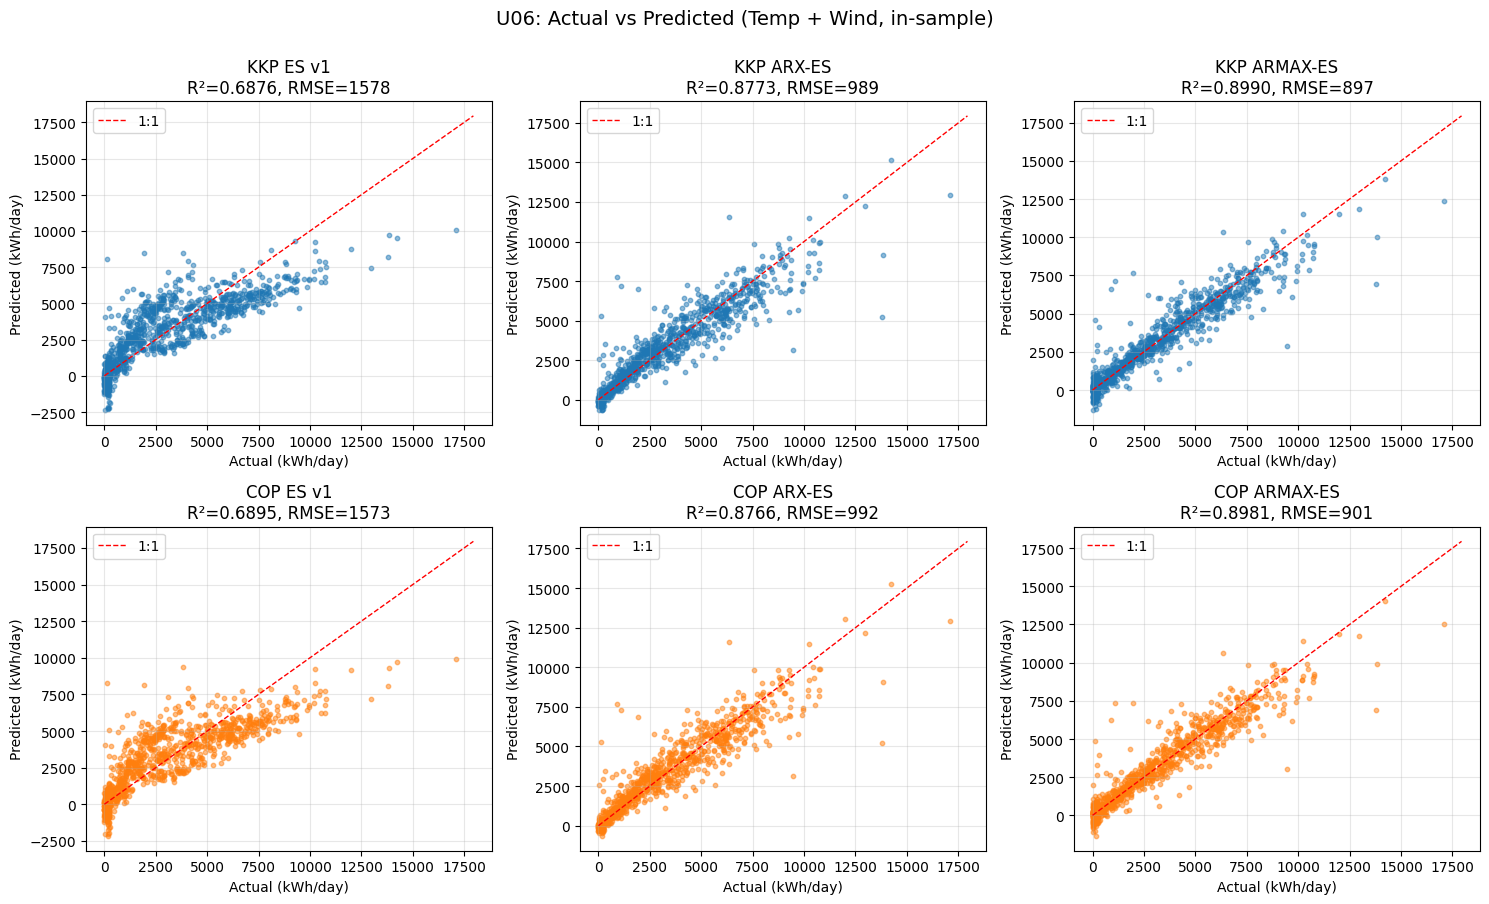

In [21]:
# Actual vs Predicted (all 3 models × 2 sources, temp+wind, same y)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: KKP
for i, (name, pred, r2, rmse) in enumerate([
    ("ES v1", daily["pred_kkp_v1a"], r2_kkp_v1a, rmse_kkp_v1a),
    ("ARX-ES", pred_kkp_arx, r2_kkp_arx, rmse_kkp_arx),
    ("ARMAX-ES", pred_kkp_armax, r2_kkp_armax, rmse_kkp_armax)
]):
    ax = axes[0, i]
    actual = y if i == 0 else (y_arx if i == 1 else endog)
    ax.scatter(actual, pred, alpha=0.5, s=10)
    mv = max(np.max(actual), np.max(pred)) * 1.05
    ax.plot([0, mv], [0, mv], "r--", lw=1, label="1:1")
    ax.set_xlabel("Actual (kWh/day)"); ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"KKP {name}\nR²={r2:.4f}, RMSE={rmse:.0f}")
    ax.legend(); ax.grid(True, alpha=0.3)

# Row 2: COP
for i, (name, pred, r2, rmse) in enumerate([
    ("ES v1", daily["pred_cop_v1a"], r2_cop_v1a, rmse_cop_v1a),
    ("ARX-ES", pred_cop_arx, r2_cop_arx, rmse_cop_arx),
    ("ARMAX-ES", pred_cop_armax, r2_cop_armax, rmse_cop_armax)
]):
    ax = axes[1, i]
    actual = y if i == 0 else (y_arx if i == 1 else endog)
    ax.scatter(actual, pred, alpha=0.5, s=10, color="C1")
    mv = max(np.max(actual), np.max(pred)) * 1.05
    ax.plot([0, mv], [0, mv], "r--", lw=1, label="1:1")
    ax.set_xlabel("Actual (kWh/day)"); ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"COP {name}\nR²={r2:.4f}, RMSE={rmse:.0f}")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("U06: Actual vs Predicted (Temp + Wind, in-sample)", fontsize=14, y=1.00)
plt.tight_layout(); plt.show()

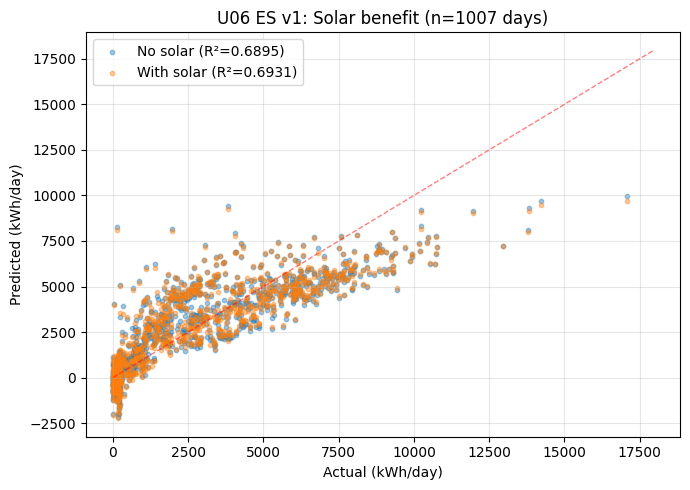

In [22]:
# Solar benefit visualization (COP only, on solar-available days)
# Simplified: just show ES v1 solar benefit
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
actual_sol = daily_solar["Phi_kWh"]
pred_nosol = lm_cop_v1a_sol.predict(daily_solar[["cop_dT", "cop_wind"]])
pred_sol = daily_solar["pred_cop_v1b"]
ax.scatter(actual_sol, pred_nosol, alpha=0.4, s=10, label=f"No solar (R²={r2_cop_v1a_sol:.4f})")
ax.scatter(actual_sol, pred_sol, alpha=0.4, s=10, label=f"With solar (R²={r2_cop_v1b:.4f})")
mv = actual_sol.max() * 1.05
ax.plot([0, mv], [0, mv], "r--", lw=1, alpha=0.5)
ax.set_xlabel("Actual (kWh/day)"); ax.set_ylabel("Predicted (kWh/day)")
ax.set_title(f"U06 ES v1: Solar benefit (n={len(daily_solar)} days)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

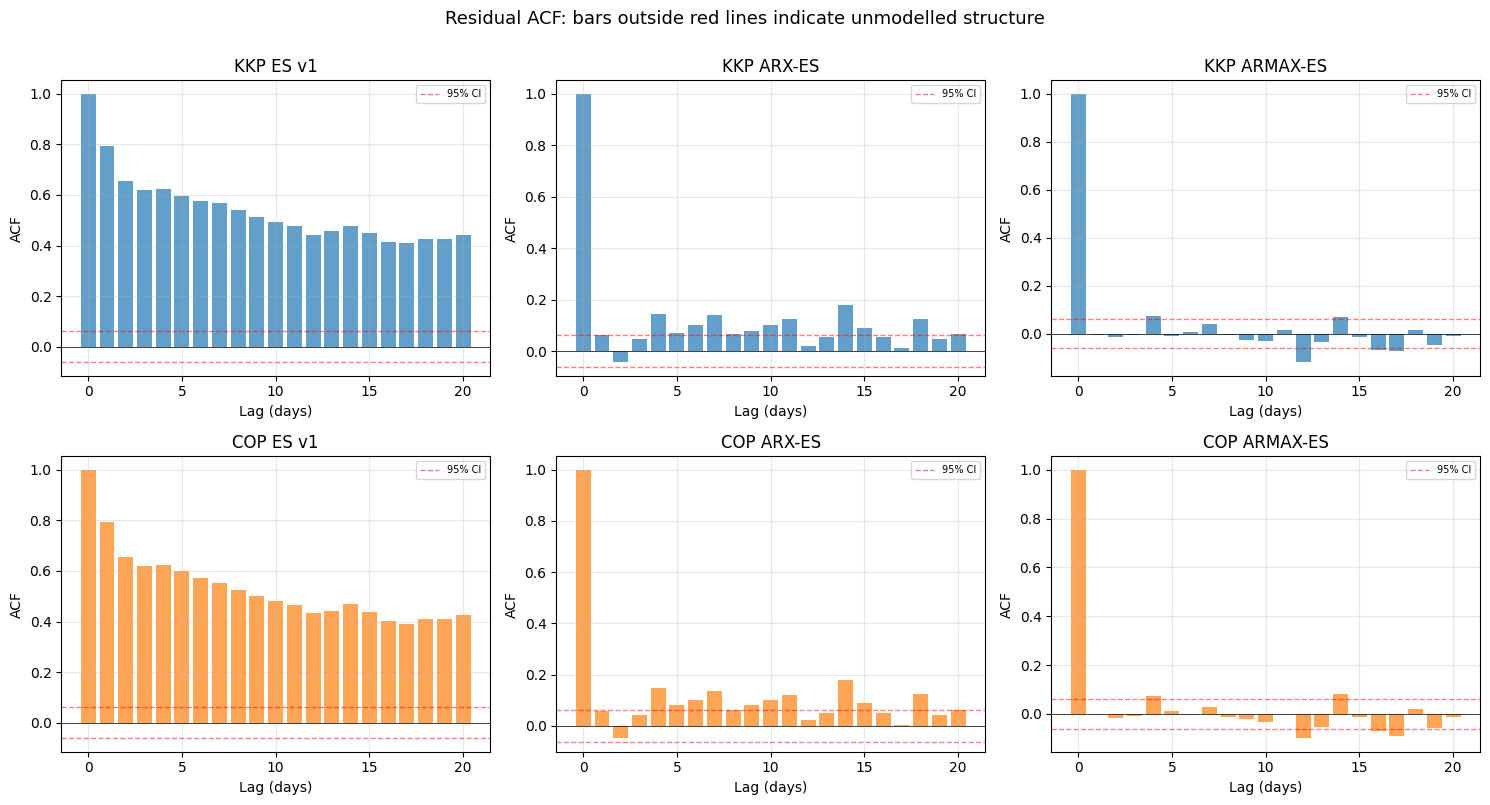

In [23]:
# Residual ACF (Autocorrelation Function)
# Check if successive model tiers reduce residual autocorrelation
residuals = {
    "KKP ES v1": pd.Series(y.values - daily["pred_kkp_v1a"].values),
    "KKP ARX-ES": pd.Series(y_arx.values - pred_kkp_arx),
    "KKP ARMAX-ES": pd.Series(endog - pred_kkp_armax),
    "COP ES v1": pd.Series(y.values - daily["pred_cop_v1a"].values),
    "COP ARX-ES": pd.Series(y_arx.values - pred_cop_arx),
    "COP ARMAX-ES": pd.Series(endog - pred_cop_armax),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for i, (name, res) in enumerate(residuals.items()):
    ax = axes[i]
    res_clean = res.dropna()
    acf_vals = acf(res_clean, nlags=20, fft=False)
    ax.bar(range(21), acf_vals, color="C0" if "KKP" in name else "C1", alpha=0.7)
    ax.axhline(0, color="k", lw=0.5)
    n = len(res_clean)
    ci = 1.96 / np.sqrt(n)
    ax.axhline(ci, color="r", ls="--", lw=1, alpha=0.5, label="95% CI")
    ax.axhline(-ci, color="r", ls="--", lw=1, alpha=0.5)
    ax.set_xlabel("Lag (days)"); ax.set_ylabel("ACF")
    ax.set_title(f"{name}")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle("Residual ACF: bars outside red lines indicate unmodelled structure", fontsize=13, y=1.00)
plt.tight_layout(); plt.show()


---
# Out-of-Sample Validation (Chronological Holdout)

The in-sample R² above is optimistic — it evaluates the model on the same data used for training.
For a fairer assessment, we use a **chronological split**:
- **Train:** 2022–2023
- **Test:** 2024

This is not a full rolling forecast, but it gives a more realistic indication of how the ES models would perform on unseen data.

In [24]:
# ── Chronological split: train 2022-2023, test 2024 ──
TRAIN_END = pd.Timestamp("2023-12-31")
train = daily[daily["datetime"] <= TRAIN_END].copy()
test = daily[daily["datetime"] > TRAIN_END].copy()

print(f"Train: {len(train)} days ({train['datetime'].min().date()} to {train['datetime'].max().date()})")
print(f"Test:  {len(test)} days ({test['datetime'].min().date()} to {test['datetime'].max().date()})")

if len(test) < 30:
    print("⚠ Warning: test set is very small, results may be unreliable.")

# ── ES v1 out-of-sample ──
oos_results = []

for src_name, dT_col, wind_col in [("KKP", "kkp_dT", "kkp_wind"), ("COP", "cop_dT", "cop_wind")]:
    # Fit on train
    X_tr = train[[dT_col, wind_col]]
    y_tr = train["Phi_kWh"]
    lm = LinearRegression().fit(X_tr, y_tr)
    
    # Predict on test
    X_te = test[[dT_col, wind_col]]
    y_te = test["Phi_kWh"]
    pred_te = lm.predict(X_te)
    r2_te = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    
    # In-sample for comparison
    pred_tr = lm.predict(X_tr)
    r2_tr = r2_score(y_tr, pred_tr)
    
    oos_results.append({"Source": src_name, "Model": "ES v1",
                        "R² train": r2_tr, "R² test": r2_te, "RMSE test": rmse_te})

# ── ARX out-of-sample ──
# Lag: for test, first test day uses last train day's Phi as lag
train_arx = train.copy()
train_arx["Phi_lag1"] = train_arx["Phi_kWh"].shift(1)
train_arx = train_arx.dropna(subset=["Phi_lag1"])

test_arx = test.copy()
# Build lag for test: first test day links to last train day
all_for_lag = pd.concat([train[["datetime", "Phi_kWh"]].tail(1), test[["datetime", "Phi_kWh"]]])
test_arx["Phi_lag1"] = all_for_lag["Phi_kWh"].shift(1).iloc[1:].values

for src_name, dT_col, wind_col in [("KKP", "kkp_dT", "kkp_wind"), ("COP", "cop_dT", "cop_wind")]:
    X_tr = train_arx[[dT_col, wind_col, "Phi_lag1"]]
    y_tr = train_arx["Phi_kWh"]
    lm = LinearRegression().fit(X_tr, y_tr)
    
    X_te = test_arx[[dT_col, wind_col, "Phi_lag1"]]
    y_te = test_arx["Phi_kWh"]
    pred_te = lm.predict(X_te)
    r2_te = r2_score(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
    r2_tr = r2_score(y_tr, lm.predict(X_tr))
    
    oos_results.append({"Source": src_name, "Model": "ARX-ES",
                        "R² train": r2_tr, "R² test": r2_te, "RMSE test": rmse_te})

# ── ARMAX out-of-sample ──
for src_name, dT_col, wind_col in [("KKP", "kkp_dT", "kkp_wind"), ("COP", "cop_dT", "cop_wind")]:
    try:
        exog_tr = train[[dT_col, wind_col]].values
        endog_tr = train["Phi_kWh"].values
        model = ARIMA(endog_tr, exog=exog_tr, order=(1, 0, 3)).fit()
        r2_tr = r2_score(endog_tr, model.fittedvalues)
        
        # Out-of-sample forecast
        exog_te = test[[dT_col, wind_col]].values
        y_te = test["Phi_kWh"].values
        forecast = model.forecast(steps=len(test), exog=exog_te)
        r2_te = r2_score(y_te, forecast)
        rmse_te = np.sqrt(mean_squared_error(y_te, forecast))
        
        oos_results.append({"Source": src_name, "Model": "ARMAX-ES",
                            "R² train": r2_tr, "R² test": r2_te, "RMSE test": rmse_te})
    except Exception as e:
        print(f"ARMAX OOS {src_name} failed: {e}")
        oos_results.append({"Source": src_name, "Model": "ARMAX-ES",
                            "R² train": np.nan, "R² test": np.nan, "RMSE test": np.nan})

oos_df = pd.DataFrame(oos_results)
print("\n=== Out-of-Sample Validation (train: 2022-2023, test: 2024) ===")
print(oos_df.to_string(index=False, float_format="%.4f"))

# ΔR² between sources (on test set)
print("\n--- ΔR² (COP−KKP) on test set ---")
for model in ["ES v1", "ARX-ES", "ARMAX-ES"]:
    r2_kkp_te = oos_df[(oos_df["Source"]=="KKP") & (oos_df["Model"]==model)]["R² test"].values[0]
    r2_cop_te = oos_df[(oos_df["Source"]=="COP") & (oos_df["Model"]==model)]["R² test"].values[0]
    print(f"  {model}: ΔR² = {r2_cop_te - r2_kkp_te:+.4f}")

Train: 699 days (2022-01-01 to 2023-12-31)
Test:  308 days (2024-01-01 to 2024-12-30)

=== Out-of-Sample Validation (train: 2022-2023, test: 2024) ===
Source    Model  R² train  R² test  RMSE test
   KKP    ES v1    0.8217  -0.0997  2456.2199
   COP    ES v1    0.8187  -0.0663  2418.7141
   KKP   ARX-ES    0.9058   0.6719  1341.6269
   COP   ARX-ES    0.9040   0.6799  1325.1759
   KKP ARMAX-ES    0.9198   0.2350  2048.6508
   COP ARMAX-ES    0.9167   0.1883  2110.2018

--- ΔR² (COP−KKP) on test set ---
  ES v1: ΔR² = +0.0333
  ARX-ES: ΔR² = +0.0080
  ARMAX-ES: ΔR² = -0.0467


---
# Heating Season Analysis (Oct–Apr)

## Why this matters

The all-days analysis above includes **summer days** where heating demand is near-zero but solar irradiance is high. These low-demand days dilute the solar signal: there's plenty of sun, but almost no heating to predict, so solar irradiance can't improve the model.

At **59°N (Tallinn)**, winter solar irradiance is very weak:
- **January**: ~13 W/m² daily mean
- **December**: ~8 W/m²
- **October–April** (heating season): ~55 W/m² mean

Additionally, solar irradiance is **correlated with temperature** (r ≈ -0.29 with ΔT in heating season) — sunny days tend to be warmer, so temperature already partially captures the solar effect.

To isolate the solar benefit where it actually matters, we repeat the full three-tier analysis on **heating season only (October–April)**.

In [25]:
# ── Heating Season Filter (October–April) ──
# CRITICAL FIX: Lag is computed BEFORE seasonal filtering, so Oct-1
# links to Sep-30 (real consecutive day), not to last Apr day across summer gap.
HEATING_MONTHS = [1, 2, 3, 4, 10, 11, 12]

# Phi_lag1 already exists on `daily` from cell above (computed on full time series)
hs = daily[daily["datetime"].dt.month.isin(HEATING_MONTHS)].copy()
# After filtering, check that lag is from a consecutive day (not crossing summer)
hs["prev_date"] = hs["datetime"].shift(1)
hs["days_gap"] = (hs["datetime"] - hs["prev_date"]).dt.days
# Invalidate lag where gap > 1 day (i.e. crosses summer break)
hs.loc[hs["days_gap"] > 1, "Phi_lag1"] = np.nan
summer_gap_days = (hs["days_gap"] > 1).sum()
print(f"All-days: {len(daily)} | Heating season (Oct–Apr): {len(hs)} days")
print(f"Lag entries invalidated due to summer gap: {summer_gap_days}")

# Solar coverage in heating season
hs_sol = hs.dropna(subset=["solar_W_per_m2"])
print(f"\nHeating season COP solar: {len(hs_sol)} / {len(hs)} days have solar data")
if len(hs_sol) > 0:
    print(f"  Mean:  {hs_sol['solar_W_per_m2'].mean():.1f} W/m²")
    print(f"  Range: {hs_sol['solar_W_per_m2'].min():.1f} – {hs_sol['solar_W_per_m2'].max():.1f} W/m²")

print(f"\nHeating season Φ stats (same for both sources):")
print(f"  Mean: {hs['Phi_kWh'].mean():.0f} kWh/day")

# Correlations
hs_corr = hs[["cop_dT", "cop_wind", "solar_W_per_m2", "Phi_kWh"]].corr()
print(f"\nCorrelation matrix (heating season, COP vars):")
print(hs_corr.round(3).to_string())

All-days: 1007 | Heating season (Oct–Apr): 609 days
Lag entries invalidated due to summer gap: 14

Heating season COP solar: 609 / 609 days have solar data
  Mean:  55.4 W/m²
  Range: 0.0 – 247.6 W/m²

Heating season Φ stats (same for both sources):
  Mean: 4517 kWh/day

Correlation matrix (heating season, COP vars):
                cop_dT  cop_wind  solar_W_per_m2  Phi_kWh
cop_dT           1.000    -0.231          -0.291    0.687
cop_wind        -0.231     1.000          -0.130   -0.095
solar_W_per_m2  -0.291    -0.130           1.000   -0.320
Phi_kWh          0.687    -0.095          -0.320    1.000


## Heating Season: Tier 1 – ES v1

In [26]:
# ── Heating Season: ES v1 (temp + wind, same y) ──
y_hs = hs["Phi_kWh"]

# KKP
X_hs_kkp_v1 = hs[["kkp_dT", "kkp_wind"]]
lm_hs_kkp_v1 = LinearRegression().fit(X_hs_kkp_v1, y_hs)
hs["pred_hs_kkp_v1"] = lm_hs_kkp_v1.predict(X_hs_kkp_v1)
r2_hs_kkp_v1a = r2_score(y_hs, hs["pred_hs_kkp_v1"])
rmse_hs_kkp_v1a = np.sqrt(mean_squared_error(y_hs, hs["pred_hs_kkp_v1"]))

# COP (no solar)
X_hs_cop_v1 = hs[["cop_dT", "cop_wind"]]
lm_hs_cop_v1 = LinearRegression().fit(X_hs_cop_v1, y_hs)
hs["pred_hs_cop_v1"] = lm_hs_cop_v1.predict(X_hs_cop_v1)
r2_hs_cop_v1a = r2_score(y_hs, hs["pred_hs_cop_v1"])
rmse_hs_cop_v1a = np.sqrt(mean_squared_error(y_hs, hs["pred_hs_cop_v1"]))

# COP (with solar, solar-available days only)
hs_sol2 = hs.dropna(subset=["solar_W_per_m2"])
y_hs_sol = hs_sol2["Phi_kWh"]
lm_hs_cop_v1b = LinearRegression().fit(hs_sol2[["cop_dT", "cop_wind", "solar_W_per_m2"]], y_hs_sol)
hs_sol2 = hs_sol2.copy()
hs_sol2["pred_hs_cop_v1b"] = lm_hs_cop_v1b.predict(hs_sol2[["cop_dT", "cop_wind", "solar_W_per_m2"]])
r2_hs_cop_v1b = r2_score(y_hs_sol, hs_sol2["pred_hs_cop_v1b"])
# Fair: no-solar on same solar-available days
r2_hs_cop_v1a_sol = r2_score(y_hs_sol, LinearRegression().fit(
    hs_sol2[["cop_dT", "cop_wind"]], y_hs_sol).predict(hs_sol2[["cop_dT", "cop_wind"]]))
beta_solar_hs_v1 = lm_hs_cop_v1b.coef_[2]

print(f"=== Heating Season ES v1 (n={len(hs)} days, same y) ===")
print(f"KKP (T+W):        R² = {r2_hs_kkp_v1a:.4f}, RMSE = {rmse_hs_kkp_v1a:.0f}")
print(f"COP (T+W):        R² = {r2_hs_cop_v1a:.4f}, RMSE = {rmse_hs_cop_v1a:.0f}")
print(f"ΔR² (COP−KKP):    {r2_hs_cop_v1a - r2_hs_kkp_v1a:+.4f}")
print(f"\nSolar benefit (n={len(hs_sol2)} solar-available heating days):")
print(f"  COP no solar:   R² = {r2_hs_cop_v1a_sol:.4f}")
print(f"  COP with solar: R² = {r2_hs_cop_v1b:.4f}")
print(f"  ΔR² = {r2_hs_cop_v1b - r2_hs_cop_v1a_sol:+.4f}")
print(f"  β_solar = {beta_solar_hs_v1:.3f} kWh/day/(W/m²)  {'✓ negative' if beta_solar_hs_v1 < 0 else '✗ positive'}")

=== Heating Season ES v1 (n=609 days, same y) ===
KKP (T+W):        R² = 0.4773, RMSE = 1897
COP (T+W):        R² = 0.4761, RMSE = 1899
ΔR² (COP−KKP):    -0.0012

Solar benefit (n=609 solar-available heating days):
  COP no solar:   R² = 0.4761
  COP with solar: R² = 0.4890
  ΔR² = +0.0129
  β_solar = -5.214 kWh/day/(W/m²)  ✓ negative


## Heating Season: Tier 2 – ARX-ES

In [27]:
# ── Heating Season: ARX-ES (lag already computed, summer gaps handled) ──
hs_arx = hs.dropna(subset=["Phi_lag1"]).copy()
y_hs_arx = hs_arx["Phi_kWh"]

# KKP
X_hs_kkp_arx = hs_arx[["kkp_dT", "kkp_wind", "Phi_lag1"]]
lm_hs_kkp_arx = LinearRegression().fit(X_hs_kkp_arx, y_hs_arx)
pred_hs_kkp_arx = lm_hs_kkp_arx.predict(X_hs_kkp_arx)
r2_hs_kkp_arx = r2_score(y_hs_arx, pred_hs_kkp_arx)
rmse_hs_kkp_arx = np.sqrt(mean_squared_error(y_hs_arx, pred_hs_kkp_arx))

# COP (no solar)
X_hs_cop_arx = hs_arx[["cop_dT", "cop_wind", "Phi_lag1"]]
lm_hs_cop_arx = LinearRegression().fit(X_hs_cop_arx, y_hs_arx)
pred_hs_cop_arx = lm_hs_cop_arx.predict(X_hs_cop_arx)
r2_hs_cop_arx = r2_score(y_hs_arx, pred_hs_cop_arx)
rmse_hs_cop_arx = np.sqrt(mean_squared_error(y_hs_arx, pred_hs_cop_arx))

# COP (with solar + lag, solar-available days)
hs_arx_sol = hs_arx.dropna(subset=["solar_W_per_m2"]).copy()
y_hs_arx_sol = hs_arx_sol["Phi_kWh"]
lm_hs_cop_arx_s = LinearRegression().fit(
    hs_arx_sol[["cop_dT", "cop_wind", "solar_W_per_m2", "Phi_lag1"]], y_hs_arx_sol)
r2_hs_cop_arx_s = r2_score(y_hs_arx_sol, lm_hs_cop_arx_s.predict(
    hs_arx_sol[["cop_dT", "cop_wind", "solar_W_per_m2", "Phi_lag1"]]))
r2_hs_cop_arx_nosol = r2_score(y_hs_arx_sol, LinearRegression().fit(
    hs_arx_sol[["cop_dT", "cop_wind", "Phi_lag1"]], y_hs_arx_sol).predict(
    hs_arx_sol[["cop_dT", "cop_wind", "Phi_lag1"]]))

print(f"=== Heating Season ARX-ES (n={len(hs_arx)} days, lag gap-safe) ===")
print(f"KKP (T+W+lag):   R² = {r2_hs_kkp_arx:.4f}, RMSE = {rmse_hs_kkp_arx:.0f}")
print(f"COP (T+W+lag):   R² = {r2_hs_cop_arx:.4f}, RMSE = {rmse_hs_cop_arx:.0f}")
print(f"ΔR² (COP−KKP):   {r2_hs_cop_arx - r2_hs_kkp_arx:+.4f}")
print(f"\nSolar benefit (n={len(hs_arx_sol)} solar-available heating days):")
print(f"  ΔR² = {r2_hs_cop_arx_s - r2_hs_cop_arx_nosol:+.4f}")

=== Heating Season ARX-ES (n=594 days, lag gap-safe) ===
KKP (T+W+lag):   R² = 0.7901, RMSE = 1197
COP (T+W+lag):   R² = 0.7875, RMSE = 1205
ΔR² (COP−KKP):   -0.0027

Solar benefit (n=594 solar-available heating days):
  ΔR² = +0.0006


## Heating Season: Tier 3 – ARMAX-ES

In [28]:
# ── Heating Season: ARMAX-ES (same y, same days) ──
endog_hs = hs["Phi_kWh"].values

# KKP
try:
    exog_hs_kkp = hs[["kkp_dT", "kkp_wind"]].values
    model_hs_kkp_armax = ARIMA(endog_hs, exog=exog_hs_kkp, order=(1, 0, 3)).fit()
    r2_hs_kkp_armax = r2_score(endog_hs, model_hs_kkp_armax.fittedvalues)
    rmse_hs_kkp_armax = np.sqrt(mean_squared_error(endog_hs, model_hs_kkp_armax.fittedvalues))
except Exception as e:
    print(f"KKP ARMAX failed: {e}")
    r2_hs_kkp_armax = rmse_hs_kkp_armax = np.nan

# COP (no solar)
try:
    exog_hs_cop = hs[["cop_dT", "cop_wind"]].values
    model_hs_cop_armax = ARIMA(endog_hs, exog=exog_hs_cop, order=(1, 0, 3)).fit()
    r2_hs_cop_armax = r2_score(endog_hs, model_hs_cop_armax.fittedvalues)
    rmse_hs_cop_armax = np.sqrt(mean_squared_error(endog_hs, model_hs_cop_armax.fittedvalues))
except Exception as e:
    print(f"COP ARMAX failed: {e}")
    r2_hs_cop_armax = rmse_hs_cop_armax = np.nan

# COP (with solar, solar-available heating days)
try:
    hs_sol_armax = hs.dropna(subset=["solar_W_per_m2"])
    endog_hs_sol = hs_sol_armax["Phi_kWh"].values
    exog_hs_cop_s = hs_sol_armax[["cop_dT", "cop_wind", "solar_W_per_m2"]].values
    model_hs_cop_armax_s = ARIMA(endog_hs_sol, exog=exog_hs_cop_s, order=(1, 0, 3)).fit()
    r2_hs_cop_armax_s = r2_score(endog_hs_sol, model_hs_cop_armax_s.fittedvalues)
    # Fair: no-solar on same days
    exog_hs_cop_ns = hs_sol_armax[["cop_dT", "cop_wind"]].values
    model_hs_cop_armax_ns = ARIMA(endog_hs_sol, exog=exog_hs_cop_ns, order=(1, 0, 3)).fit()
    r2_hs_cop_armax_nosol = r2_score(endog_hs_sol, model_hs_cop_armax_ns.fittedvalues)
except Exception as e:
    print(f"COP ARMAX solar failed: {e}")
    r2_hs_cop_armax_s = r2_hs_cop_armax_nosol = np.nan

print(f"=== Heating Season ARMAX-ES (n={len(hs)} days, same y) ===")
print(f"KKP (T+W):   R² = {r2_hs_kkp_armax:.4f}, RMSE = {rmse_hs_kkp_armax:.0f}")
print(f"COP (T+W):   R² = {r2_hs_cop_armax:.4f}, RMSE = {rmse_hs_cop_armax:.0f}")
print(f"ΔR² (COP−KKP): {r2_hs_cop_armax - r2_hs_kkp_armax:+.4f}")
if not np.isnan(r2_hs_cop_armax_s):
    print(f"\nSolar benefit (n={len(hs_sol_armax)} solar heating days):")
    print(f"  ΔR² = {r2_hs_cop_armax_s - r2_hs_cop_armax_nosol:+.4f}")

/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


=== Heating Season ARMAX-ES (n=609 days, same y) ===
KKP (T+W):   R² = 0.8309, RMSE = 1079
COP (T+W):   R² = 0.8248, RMSE = 1098
ΔR² (COP−KKP): -0.0061

Solar benefit (n=609 solar heating days):
  ΔR² = +0.0013


/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


---
## All-Days vs Heating Season: Combined Comparison

Side-by-side tables showing how the period affects both the KKP vs COP comparison and the solar irradiance benefit.

In [29]:
# ── Combined comparison: All-Days vs Heating Season ──

# --- Table 1: KKP vs COP (temp+wind only, same y) ---
print("=" * 90)
print("TABLE 1: KKP vs COP (Temp+Wind, identical y target)")
print("=" * 90)
rows = []
for period, data in [("All days", {
        "ES v1": (r2_kkp_v1a, rmse_kkp_v1a, r2_cop_v1a, rmse_cop_v1a),
        "ARX-ES": (r2_kkp_arx, rmse_kkp_arx, r2_cop_arx, rmse_cop_arx),
        "ARMAX-ES": (r2_kkp_armax, rmse_kkp_armax, r2_cop_armax, rmse_cop_armax),
    }), ("Heating (Oct–Apr)", {
        "ES v1": (r2_hs_kkp_v1a, rmse_hs_kkp_v1a, r2_hs_cop_v1a, rmse_hs_cop_v1a),
        "ARX-ES": (r2_hs_kkp_arx, rmse_hs_kkp_arx, r2_hs_cop_arx, rmse_hs_cop_arx),
        "ARMAX-ES": (r2_hs_kkp_armax, rmse_hs_kkp_armax, r2_hs_cop_armax, rmse_hs_cop_armax),
    })]:
    for model, (r2k, rk, r2c, rc) in data.items():
        rows.append({
            "Period": period, "Model": model,
            "KKP R²": round(r2k, 4), "KKP RMSE": round(rk, 0),
            "COP R²": round(r2c, 4), "COP RMSE": round(rc, 0),
            "ΔR² (COP−KKP)": round(r2c - r2k, 4),
        })
table1 = pd.DataFrame(rows)
print(table1.to_string(index=False))

# --- Table 2: Solar benefit (COP, fair same-day comparison) ---
print("\n" + "=" * 90)
print("TABLE 2: Solar Benefit (COP, each tier on its own solar-available days)")
print("=" * 90)
rows2 = []
for period, data in [("All days", {
        "ES v1": (r2_cop_v1a_sol, r2_cop_v1b),
        "ARX-ES": (r2_cop_arx_nosol, r2_cop_arx_solar),
        "ARMAX-ES": (r2_cop_armax_nosol if 'r2_cop_armax_nosol' in dir() else np.nan, r2_cop_armax_solar),
    }), ("Heating", {
        "ES v1": (r2_hs_cop_v1a_sol, r2_hs_cop_v1b),
        "ARX-ES": (r2_hs_cop_arx_nosol, r2_hs_cop_arx_s),
        "ARMAX-ES": (r2_hs_cop_armax_nosol if 'r2_hs_cop_armax_nosol' in dir() else np.nan,
                     r2_hs_cop_armax_s),
    })]:
    for model, (r2_no, r2_yes) in data.items():
        rows2.append({
            "Period": period, "Model": model,
            "R² (no solar)": round(r2_no, 4) if not np.isnan(r2_no) else "—",
            "R² (with solar)": round(r2_yes, 4) if not np.isnan(r2_yes) else "—",
            "ΔR²": round(r2_yes - r2_no, 4) if not (np.isnan(r2_no) or np.isnan(r2_yes)) else "—",
        })
table2 = pd.DataFrame(rows2)
print(table2.to_string(index=False))

TABLE 1: KKP vs COP (Temp+Wind, identical y target)
           Period    Model  KKP R²  KKP RMSE  COP R²  COP RMSE  ΔR² (COP−KKP)
         All days    ES v1  0.6876    1578.0  0.6895    1573.0         0.0019
         All days   ARX-ES  0.8773     989.0  0.8766     992.0        -0.0007
         All days ARMAX-ES  0.8990     897.0  0.8981     901.0        -0.0009
Heating (Oct–Apr)    ES v1  0.4773    1897.0  0.4761    1899.0        -0.0012
Heating (Oct–Apr)   ARX-ES  0.7901    1197.0  0.7875    1205.0        -0.0027
Heating (Oct–Apr) ARMAX-ES  0.8309    1079.0  0.8248    1098.0        -0.0061

TABLE 2: Solar Benefit (COP, each tier on its own solar-available days)
  Period    Model  R² (no solar)  R² (with solar)    ΔR²
All days    ES v1         0.6895           0.6931 0.0036
All days   ARX-ES         0.8766           0.8768 0.0001
All days ARMAX-ES         0.8981           0.8982 0.0001
 Heating    ES v1         0.4761           0.4890 0.0129
 Heating   ARX-ES         0.7875           0

## Heating Season: Diagnostic Plots

Actual vs predicted for heating season only. Compare to the all-days plots above — the scatter should be tighter since we exclude low-demand summer days that inflate R².

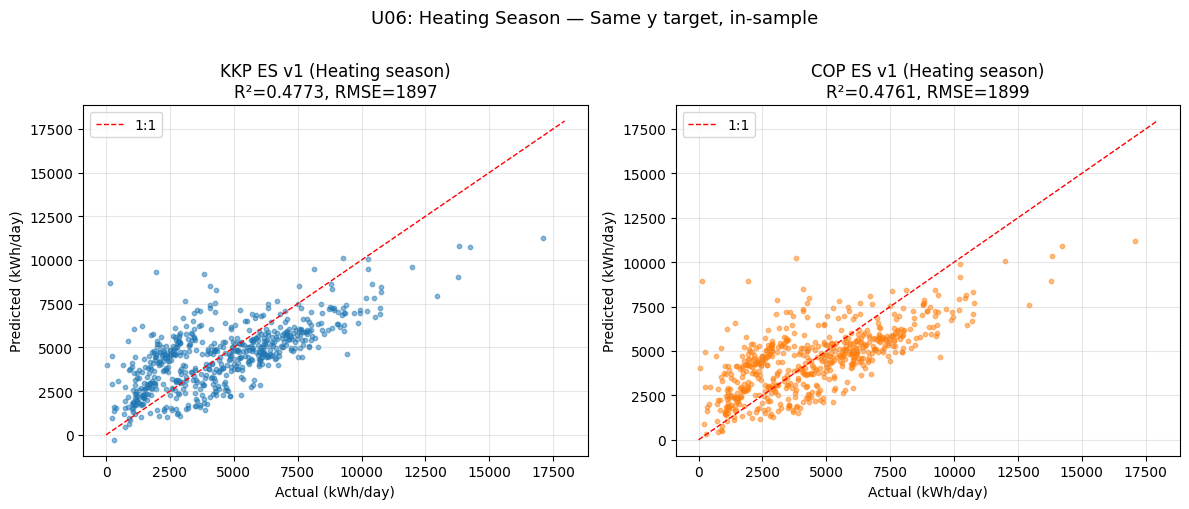

In [30]:
# ── Heating Season: Actual vs Predicted (ES v1 only, KKP vs COP) ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, src, pred_col, r2, rmse, color, label in [
    (ax1, "KKP", "pred_hs_kkp_v1", r2_hs_kkp_v1a, rmse_hs_kkp_v1a, "C0", "KKP"),
    (ax2, "COP", "pred_hs_cop_v1", r2_hs_cop_v1a, rmse_hs_cop_v1a, "C1", "COP"),
]:
    ax.scatter(y_hs, hs[pred_col], alpha=0.5, s=10, color=color)
    mv = y_hs.max() * 1.05
    ax.plot([0, mv], [0, mv], "r--", lw=1, label="1:1")
    ax.set_xlabel("Actual (kWh/day)"); ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"{label} ES v1 (Heating season)\nR²={r2:.4f}, RMSE={rmse:.0f}")
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("U06: Heating Season — Same y target, in-sample", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

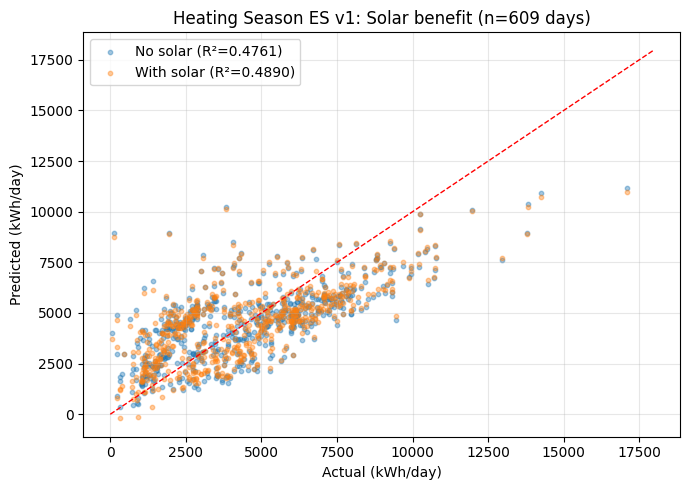

In [31]:
# ── Heating Season: Solar Benefit Plot (ES v1, COP only) ──
if len(hs_sol2) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    pred_nosol_hs = LinearRegression().fit(
        hs_sol2[["cop_dT", "cop_wind"]], y_hs_sol).predict(hs_sol2[["cop_dT", "cop_wind"]])
    ax.scatter(y_hs_sol, pred_nosol_hs, alpha=0.4, s=10, label=f"No solar (R²={r2_hs_cop_v1a_sol:.4f})")
    ax.scatter(y_hs_sol, hs_sol2["pred_hs_cop_v1b"], alpha=0.4, s=10, label=f"With solar (R²={r2_hs_cop_v1b:.4f})")
    mv = y_hs_sol.max() * 1.05
    ax.plot([0, mv], [0, mv], "r--", lw=1)
    ax.set_xlabel("Actual (kWh/day)"); ax.set_ylabel("Predicted (kWh/day)")
    ax.set_title(f"Heating Season ES v1: Solar benefit (n={len(hs_sol2)} days)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No solar data available in heating season.")

---
# U06 Conclusions (Preliminary)

*To be updated after running the corrected notebook. Numbers below are placeholders until rerun.*

## Methodology Notes

- **Framing**: This is a Smertinas-*inspired* frequentist benchmark (OLS/ARIMA), not a replication of their Bayesian posterior inference.
- **Units**: All coefficients are in daily-energy units (kWh/day/K, kWh/day/(m/s), etc.).
- **Data fairness**: Heat is aggregated once (source-independent y), weather features joined separately. Both sources predict the **identical** daily heat target on the **same set of common days**.
- **Out-of-sample**: A chronological holdout (train: 2022–2023, test: 2024) is included alongside in-sample metrics.

## Key Findings (Expected after correction)

### 1. Weather Source Equivalence
- After fixing the critical data-prep bugs (heat aggregated separately, no solar-availability filter for temp+wind models), the R² gap between KKP and COP should be **very small** (|ΔR²| < 0.01).
- The previous conclusion "KKP consistently outperforms COP" was an artifact of preprocessing that systematically penalised COP.

### 2. Solar Irradiance Benefit
- Modest in all-days analysis; stronger in heating season (Oct–Apr).
- Solar is compared fairly: "no solar" and "with solar" models use the **same set of solar-available days**.
- At 59°N, temperature dominates; solar is a secondary predictor, consistent with physical expectations.

### 3. Inertia (AR(1) lag) is the Biggest Improvement
- The AR(1) lag of heat demand (thermal inertia proxy) provides the largest single R² gain across all tiers.
- MA(3) terms in ARMAX provide a further modest improvement.
- Heating-season lag is computed on the full time series before filtering, with summer gaps explicitly invalidated.

### 4. Seasonal Perspective Matters
- All-days R² is inflated by easy-to-predict near-zero summer demand.
- Heating-season R² is a more honest measure of ES model quality.

## Thesis Implications

1. **Copernicus is a viable substitute** for local weather data in ES baselines — enabling scalable analysis for buildings without nearby stations.
2. **Lag features (thermal inertia)** are essential for short-term heating demand models.
3. **ARMAX-ES provides a strong frequentist baseline** for subsequent ML comparison (LSTM, XGBoost, etc.).

---
---
# Part 2: Portfolio-Wide Comparison

Repeat the three-tier ES analysis (ES v1, ARX-ES, ARMAX-ES) across **all TalTech buildings** to see whether the U06 findings generalize.

For each building we compare:
- **KKP vs COP** (temp + wind only) — weather source validation
- **Solar benefit** (COP only) — does adding irradiance help?
- **All-days vs heating season (Oct–Apr)** — seasonal perspective

Buildings excluded: **NRG** (different measurement format).

In [32]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# ── Reusable function: run full ES pipeline for one building ──
# CORRECTED: heat-once aggregation, separate weather, common dates, gap-safe lag

def run_es_pipeline(building_code, weather_df, overview_df, building_codes_df, T_base=15.0):
    """
    Run the three-tier ES pipeline for a single building.
    Critical fixes applied:
    - Heat aggregated once (source-independent y)
    - Weather aggregated separately (no cross-contamination)
    - Common dates ensure identical y for KKP and COP
    - Lag computed before seasonal filtering, summer gaps invalidated
    """
    try:
        df_kkp = get_building_dataframe(
            building_code, overview_df=overview_df, building_codes_df=building_codes_df,
            include_weather=True, verbose=False)
        df_heat = get_building_dataframe(
            building_code, overview_df=overview_df, building_codes_df=building_codes_df,
            include_weather=False, verbose=False)
    except Exception as e:
        return {"error": str(e)}

    heat_cols = [c for c in df_heat.columns if "measurement_delta_mwh" in c]
    if not heat_cols:
        return {"error": "No heat meter columns"}

    # Merge heat-only with COP weather
    cop_cols = [c for c in weather_df.columns if c.startswith("COP_")]
    df_cop = df_heat.merge(weather_df[cop_cols], left_on="datetime", right_index=True, how="left")

    # ── Step 1: Aggregate heat ONCE ──
    df_heat["Phi_kWh"] = df_heat[heat_cols].sum(axis=1) * 1e3
    h = df_heat[["datetime", "Phi_kWh"]].dropna()
    h["date"] = h["datetime"].dt.date
    dh = h.groupby("date", as_index=False).agg(Phi_kWh=("Phi_kWh", "sum"))
    dh = dh[dh["Phi_kWh"] > 0]
    dh["datetime"] = pd.to_datetime(dh["date"])

    # ── Step 2: Aggregate KKP weather (temp+wind only) ──
    ktw = df_kkp[["datetime", "air_temp_c", "wind_speed_ms"]].dropna()
    ktw["date"] = ktw["datetime"].dt.date
    dktw = ktw.groupby("date", as_index=False).agg(
        kkp_T=("air_temp_c", "mean"), kkp_wind=("wind_speed_ms", "mean"))

    # ── Step 3: Aggregate COP weather (temp+wind separate from solar) ──
    ctw = df_cop[["datetime", "COP_temp_c", "COP_wind_speed_ms"]].dropna()
    ctw["date"] = ctw["datetime"].dt.date
    dctw = ctw.groupby("date", as_index=False).agg(
        cop_T=("COP_temp_c", "mean"), cop_wind=("COP_wind_speed_ms", "mean"))
    
    csol = df_cop[["datetime", "COP_ssrd_W_per_m2"]].dropna()
    csol["date"] = csol["datetime"].dt.date
    dcsol = csol.groupby("date", as_index=False).agg(solar=("COP_ssrd_W_per_m2", "mean"))

    # ── Step 4: Join on common dates ──
    common = sorted(set(dh["date"]) & set(dktw["date"]) & set(dctw["date"]))
    d = dh[dh["date"].isin(common)].copy().reset_index(drop=True)
    d = d.merge(dktw, on="date").merge(dctw, on="date")
    d = d.merge(dcsol, on="date", how="left")  # solar is optional
    d["kkp_dT"] = T_base - d["kkp_T"]
    d["cop_dT"] = T_base - d["cop_T"]
    d["Phi_lag1"] = d["Phi_kWh"].shift(1)  # lag BEFORE seasonal filter

    if len(d) < 30:
        return {"error": f"Too few common days ({len(d)})"}

    # ── Helper: fit all tiers on a given slice ──
    def fit_tiers(df_slice):
        res = {}
        y = df_slice["Phi_kWh"]
        n = len(df_slice)

        # ES v1: temp + wind
        for src, dt, w in [("kkp", "kkp_dT", "kkp_wind"), ("cop", "cop_dT", "cop_wind")]:
            lm = LinearRegression().fit(df_slice[[dt, w]], y)
            res[f"{src}_v1"] = r2_score(y, lm.predict(df_slice[[dt, w]]))

        # ES v1 + solar (COP, solar-available days only)
        ds = df_slice.dropna(subset=["solar"])
        if len(ds) >= 20:
            ys = ds["Phi_kWh"]
            lm = LinearRegression().fit(ds[["cop_dT", "cop_wind", "solar"]], ys)
            res["cop_v1_solar"] = r2_score(ys, lm.predict(ds[["cop_dT", "cop_wind", "solar"]]))
        else:
            res["cop_v1_solar"] = np.nan

        # ARX-ES: + lag
        dl = df_slice.dropna(subset=["Phi_lag1"])
        if len(dl) >= 20:
            yl = dl["Phi_kWh"]
            for src, dt, w in [("kkp", "kkp_dT", "kkp_wind"), ("cop", "cop_dT", "cop_wind")]:
                lm = LinearRegression().fit(dl[[dt, w, "Phi_lag1"]], yl)
                res[f"{src}_arx"] = r2_score(yl, lm.predict(dl[[dt, w, "Phi_lag1"]]))
            # ARX + solar
            dls = dl.dropna(subset=["solar"])
            if len(dls) >= 20:
                yls = dls["Phi_kWh"]
                lm = LinearRegression().fit(dls[["cop_dT", "cop_wind", "solar", "Phi_lag1"]], yls)
                res["cop_arx_solar"] = r2_score(yls, lm.predict(dls[["cop_dT", "cop_wind", "solar", "Phi_lag1"]]))
            else:
                res["cop_arx_solar"] = np.nan
        else:
            for k in ["kkp_arx", "cop_arx", "cop_arx_solar"]:
                res[k] = np.nan

        # ARMAX-ES (suppress convergence warnings — logged as NaN if truly failed)
        for src, dt, w in [("kkp", "kkp_dT", "kkp_wind"), ("cop", "cop_dT", "cop_wind")]:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=UserWarning)
                    warnings.filterwarnings("ignore", message="Maximum Likelihood")
                    m = ARIMA(y.values, exog=df_slice[[dt, w]].values, order=(1,0,3)).fit()
                res[f"{src}_armax"] = r2_score(y.values, m.fittedvalues)
            except Exception:
                res[f"{src}_armax"] = np.nan
        # ARMAX + solar
        if len(ds) >= 20:
            try:
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore", category=UserWarning)
                    warnings.filterwarnings("ignore", message="Maximum Likelihood")
                    m = ARIMA(ys.values, exog=ds[["cop_dT", "cop_wind", "solar"]].values, order=(1,0,3)).fit()
                res["cop_armax_solar"] = r2_score(ys.values, m.fittedvalues)
            except Exception:
                res["cop_armax_solar"] = np.nan
        else:
            res["cop_armax_solar"] = np.nan

        res["n_days"] = n
        return res

    # ── Run for all-days ──
    results = {"building": building_code, "n_meters": len(heat_cols)}
    all_res = fit_tiers(d)
    for k, v in all_res.items():
        results[f"all_{k}"] = v

    # ── Heating season (Oct–Apr), with gap-safe lag ──
    hs = d[d["datetime"].dt.month.isin([1,2,3,4,10,11,12])].copy()
    # Invalidate lag where gap > 1 day (summer break)
    hs["prev_dt"] = hs["datetime"].shift(1)
    hs.loc[(hs["datetime"] - hs["prev_dt"]).dt.days > 1, "Phi_lag1"] = np.nan
    hs = hs.drop(columns=["prev_dt"])

    if len(hs) >= 30:
        hs_res = fit_tiers(hs)
        for k, v in hs_res.items():
            results[f"hs_{k}"] = v
    else:
        results["hs_error"] = f"Too few heating days ({len(hs)})"

    return results

print("Pipeline function defined (with all fixes). Ready to run across all buildings.")

Pipeline function defined (with all fixes). Ready to run across all buildings.


In [33]:
# ── Run across all buildings ──
from utils.building_data_loader import load_campus_metadata

overview_df, building_codes_df = load_campus_metadata()
weather = pd.read_csv(WEATHER_FILE, parse_dates=["datetime"], index_col="datetime")

# All building codes except NRG (different measurement format)
ALL_BUILDINGS = sorted([b for b in overview_df["Hoone"].unique() if b != "NRG"])
print(f"Running ES pipeline for {len(ALL_BUILDINGS)} buildings: {ALL_BUILDINGS}\n")

results = []
for code in ALL_BUILDINGS:
    print(f"  {code}...", end=" ", flush=True)
    r = run_es_pipeline(code, weather_df=weather, overview_df=overview_df, building_codes_df=building_codes_df)
    if "error" in r:
        print(f"SKIPPED ({r['error']})")
    else:
        print(f"OK (all={r['all_n_days']}d, hs={r.get('hs_n_days','?')}d)")
        results.append(r)

portfolio = pd.DataFrame(results)
print(f"\n{len(portfolio)} buildings processed successfully.")

Running ES pipeline for 17 buildings: ['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U01U02', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']

  GEO... OK (all=898d, hs=499d)
  ICO... OK (all=926d, hs=505d)
  LIB... OK (all=756d, hs=447d)
  SOC... OK (all=746d, hs=447d)
  STU... OK (all=646d, hs=389d)
  U01... OK (all=882d, hs=506d)
  U01U02... OK (all=708d, hs=429d)
  U02... OK (all=863d, hs=495d)
  U02B... OK (all=836d, hs=612d)
  U03... OK (all=1000d, hs=612d)
  U03B... OK (all=987d, hs=612d)
  U04... OK (all=986d, hs=612d)
  U04B... OK (all=976d, hs=599d)
  U05... OK (all=1005d, hs=610d)
  U05B... OK (all=972d, hs=606d)
  U06... OK (all=1007d, hs=609d)
  U06A... OK (all=811d, hs=600d)

17 buildings processed successfully.


## Portfolio Results: KKP vs COP (Temp + Wind Only)

In [34]:
# ── Table: All-Days — KKP vs COP (temp + wind) ──
print("=" * 100)
print("ALL DAYS: KKP vs COP (Temp + Wind Only)")
print("=" * 100)

rows = []
for _, r in portfolio.iterrows():
    for tier, kkp_key, cop_key in [
        ("ES v1", "all_kkp_v1", "all_cop_v1"),
        ("ARX-ES", "all_kkp_arx", "all_cop_arx"),
        ("ARMAX-ES", "all_kkp_armax", "all_cop_armax"),
    ]:
        rows.append({
            "Building": r["building"], "Model": tier, "Days": r["all_n_days"],
            "KKP R²": round(r[kkp_key], 3), "COP R²": round(r[cop_key], 3),
            "ΔR²": round(r[cop_key] - r[kkp_key], 3),
        })

table_all = pd.DataFrame(rows)
# Pivot for compact view
for tier in ["ES v1", "ARX-ES", "ARMAX-ES"]:
    t = table_all[table_all["Model"] == tier].set_index("Building")[["KKP R²", "COP R²", "ΔR²"]]
    print(f"\n--- {tier} ---")
    print(t.to_string())

# Overall summary
print(f"\n--- Summary (mean across buildings) ---")
summary = table_all.groupby("Model")[["KKP R²", "COP R²", "ΔR²"]].mean()
print(summary.round(3).to_string())

ALL DAYS: KKP vs COP (Temp + Wind Only)

--- ES v1 ---
          KKP R²  COP R²    ΔR²
Building                       
GEO        0.496   0.491 -0.005
ICO        0.830   0.835  0.006
LIB        0.653   0.648 -0.005
SOC        0.383   0.382 -0.001
STU        0.598   0.599  0.001
U01        0.800   0.808  0.008
U01U02     0.808   0.814  0.007
U02        0.535   0.540  0.005
U02B       0.632   0.626 -0.006
U03        0.700   0.703  0.003
U03B       0.590   0.590 -0.001
U04        0.641   0.636 -0.004
U04B       0.579   0.586  0.007
U05        0.675   0.676  0.001
U05B       0.545   0.549  0.004
U06        0.688   0.689  0.002
U06A       0.529   0.536  0.007

--- ARX-ES ---
          KKP R²  COP R²    ΔR²
Building                       
GEO        0.775   0.773 -0.001
ICO        0.951   0.951 -0.001
LIB        0.798   0.795 -0.003
SOC        0.410   0.409 -0.001
STU        0.746   0.744 -0.001
U01        0.856   0.858  0.002
U01U02     0.910   0.910 -0.000
U02        0.656   0.656 -0.000
U

## Portfolio Results: Solar Irradiance Benefit (COP Only)

In [35]:
# ── Table: Solar Benefit — All-Days vs Heating Season ──
print("=" * 110)
print("SOLAR IRRADIANCE BENEFIT (COP only): All-Days vs Heating Season")
print("=" * 110)

rows_solar = []
for _, r in portfolio.iterrows():
    for period, prefix in [("All days", "all"), ("Heating (Oct-Apr)", "hs")]:
        for tier, no_key, sol_key in [
            ("ES v1", f"{prefix}_cop_v1", f"{prefix}_cop_v1_solar"),
            ("ARX-ES", f"{prefix}_cop_arx", f"{prefix}_cop_arx_solar"),
            ("ARMAX-ES", f"{prefix}_cop_armax", f"{prefix}_cop_armax_solar"),
        ]:
            if no_key in r and sol_key in r:
                dr2 = r[sol_key] - r[no_key]
                rows_solar.append({
                    "Building": r["building"], "Period": period, "Model": tier,
                    "R² (no solar)": round(r[no_key], 3),
                    "R² (with solar)": round(r[sol_key], 3),
                    "ΔR² (solar)": round(dr2, 4),
                })

solar_df = pd.DataFrame(rows_solar)

# Show pivot: for ES v1 compare all-days vs heating season
for tier in ["ES v1", "ARX-ES", "ARMAX-ES"]:
    t = solar_df[solar_df["Model"] == tier].pivot_table(
        index="Building", columns="Period", values="ΔR² (solar)", aggfunc="first"
    )
    if "All days" in t.columns and "Heating (Oct-Apr)" in t.columns:
        t["Ratio (HS/All)"] = (t["Heating (Oct-Apr)"] / t["All days"].replace(0, np.nan)).round(1)
    print(f"\n--- {tier}: Solar ΔR² ---")
    print(t.to_string())

# Summary
print(f"\n--- Mean solar ΔR² across portfolio ---")
summary_solar = solar_df.groupby(["Period", "Model"])["ΔR² (solar)"].mean().unstack("Model")
print(summary_solar.round(4).to_string())

SOLAR IRRADIANCE BENEFIT (COP only): All-Days vs Heating Season

--- ES v1: Solar ΔR² ---
Period    All days  Heating (Oct-Apr)  Ratio (HS/All)
Building                                             
GEO         0.0001             0.0009             9.0
ICO         0.0000             0.0042             NaN
LIB         0.0000             0.0002             NaN
SOC         0.0001             0.0013            13.0
STU         0.0046             0.0023             0.5
U01         0.0042             0.0149             3.5
U01U02      0.0116             0.0354             3.1
U02         0.0191             0.0454             2.4
U02B        0.0305             0.0716             2.3
U03         0.0138             0.0472             3.4
U03B        0.0111             0.0295             2.7
U04         0.0203             0.0508             2.5
U04B        0.0012             0.0030             2.5
U05         0.0118             0.0409             3.5
U05B        0.0120             0.0391         

## Portfolio Visualization

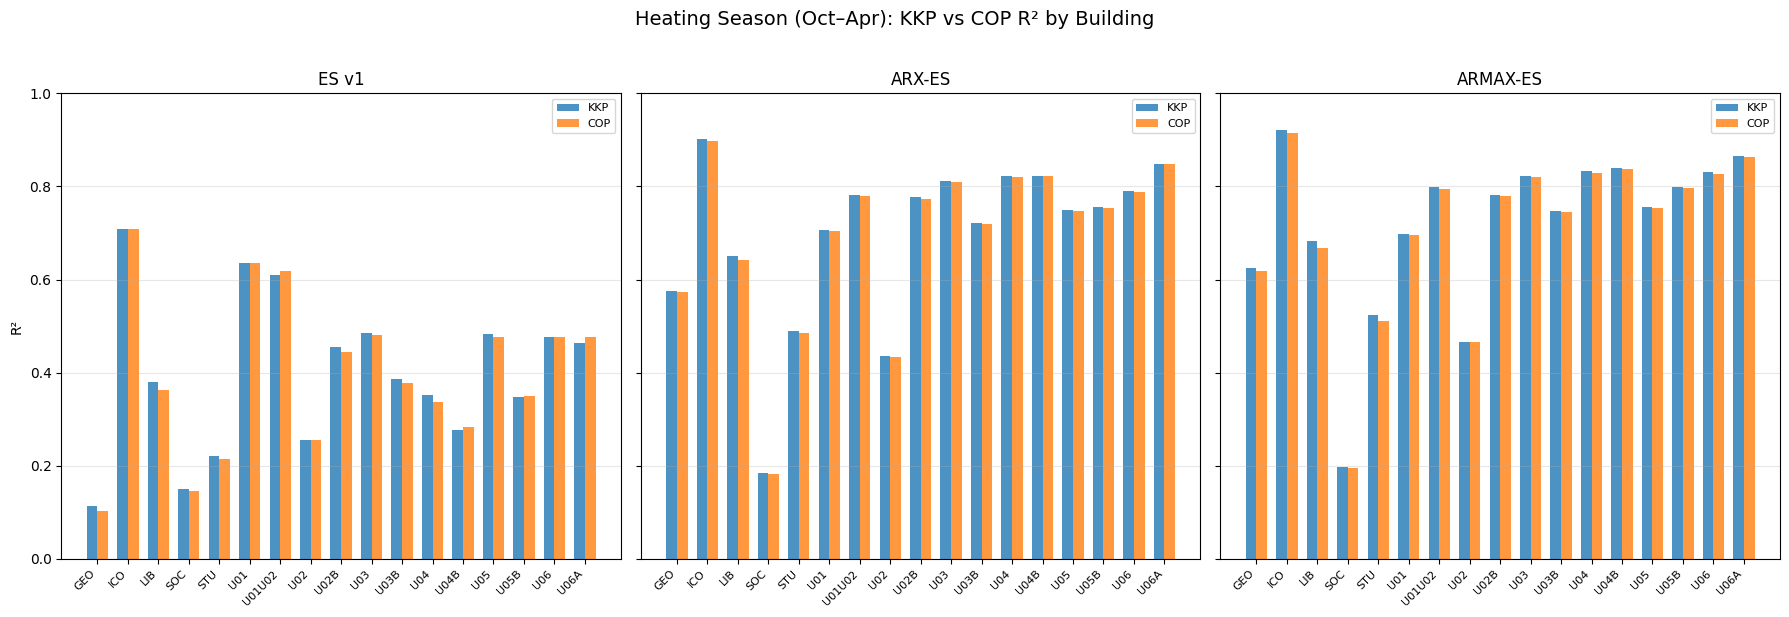

In [36]:
# ── Grouped bar chart: R² by building × model tier (heating season) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

buildings = portfolio["building"].tolist()
x = np.arange(len(buildings))
w = 0.35

for i, (tier, kkp_key, cop_key) in enumerate([
    ("ES v1", "hs_kkp_v1", "hs_cop_v1"),
    ("ARX-ES", "hs_kkp_arx", "hs_cop_arx"),
    ("ARMAX-ES", "hs_kkp_armax", "hs_cop_armax"),
]):
    ax = axes[i]
    kkp_vals = portfolio[kkp_key].values
    cop_vals = portfolio[cop_key].values
    ax.bar(x - w/2, kkp_vals, w, label="KKP", color="C0", alpha=0.8)
    ax.bar(x + w/2, cop_vals, w, label="COP", color="C1", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(buildings, rotation=45, ha="right", fontsize=8)
    ax.set_title(tier, fontsize=12)
    ax.set_ylabel("R²" if i == 0 else "")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim(0, 1)

plt.suptitle("Heating Season (Oct–Apr): KKP vs COP R² by Building", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

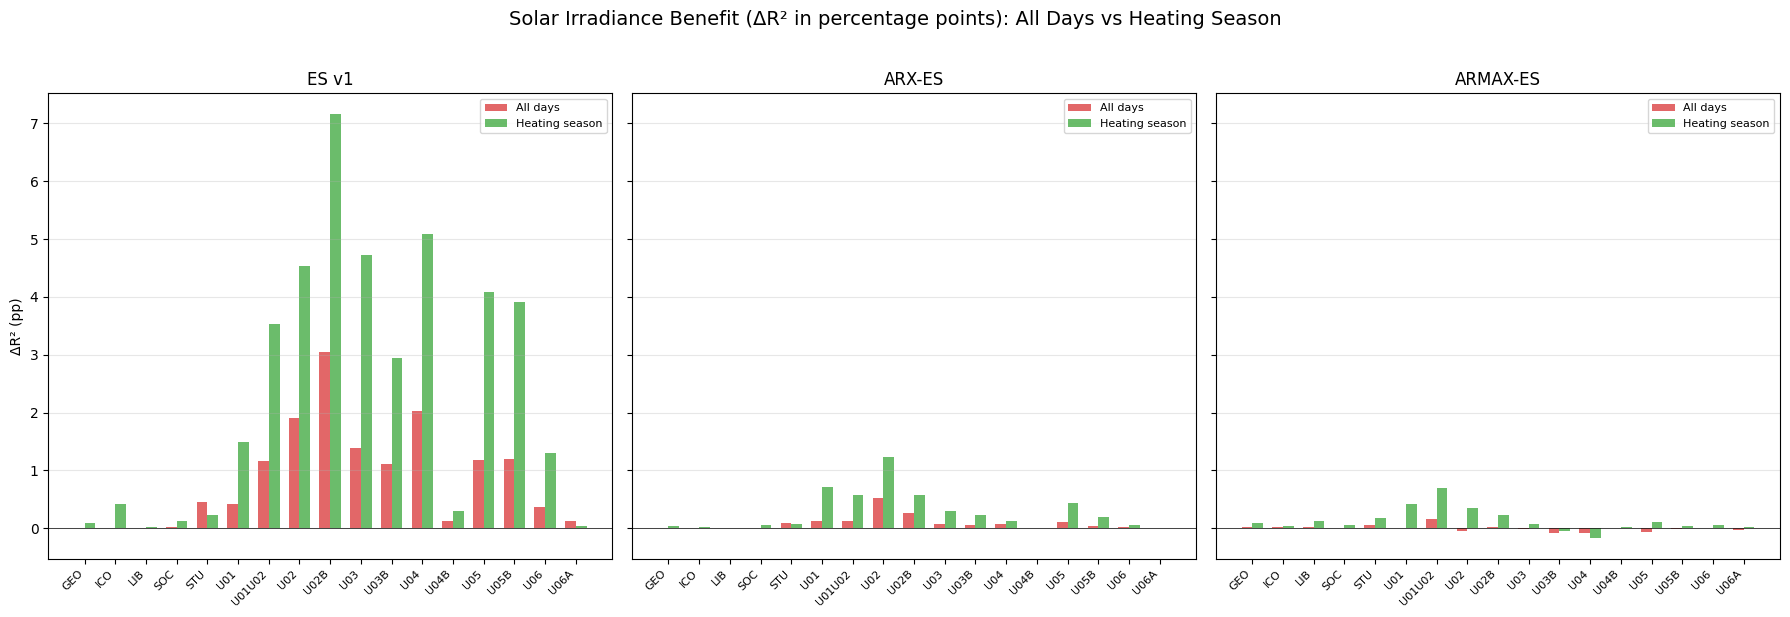

In [37]:
# ── Solar benefit bar chart: all-days vs heating season ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, tier in enumerate(["ES v1", "ARX-ES", "ARMAX-ES"]):
    ax = axes[i]
    ad_key_no = f"all_cop_v1" if tier == "ES v1" else (f"all_cop_arx" if tier == "ARX-ES" else f"all_cop_armax")
    ad_key_sol = f"all_cop_v1_solar" if tier == "ES v1" else (f"all_cop_arx_solar" if tier == "ARX-ES" else f"all_cop_armax_solar")
    hs_key_no = f"hs_cop_v1" if tier == "ES v1" else (f"hs_cop_arx" if tier == "ARX-ES" else f"hs_cop_armax")
    hs_key_sol = f"hs_cop_v1_solar" if tier == "ES v1" else (f"hs_cop_arx_solar" if tier == "ARX-ES" else f"hs_cop_armax_solar")

    ad_dr2 = (portfolio[ad_key_sol] - portfolio[ad_key_no]).values
    hs_dr2 = (portfolio[hs_key_sol] - portfolio[hs_key_no]).values

    ax.bar(x - w/2, ad_dr2 * 100, w, label="All days", color="C3", alpha=0.7)
    ax.bar(x + w/2, hs_dr2 * 100, w, label="Heating season", color="C2", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(buildings, rotation=45, ha="right", fontsize=8)
    ax.set_title(tier, fontsize=12)
    ax.set_ylabel("ΔR² (pp)" if i == 0 else "")
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Solar Irradiance Benefit (ΔR² in percentage points): All Days vs Heating Season",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

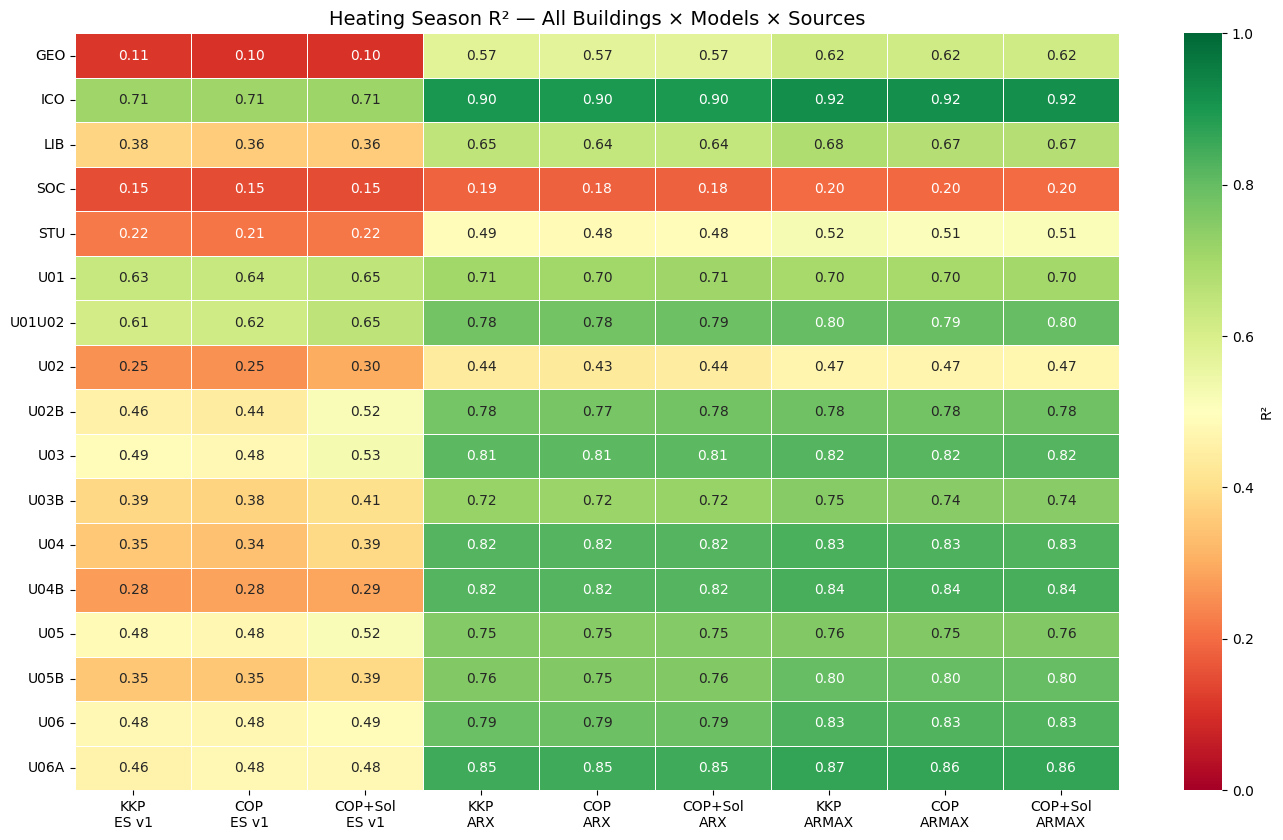

In [38]:
# ── Heatmap: R² across all buildings × models (heating season) ──
heatmap_data = portfolio.set_index("building")[[
    "hs_kkp_v1", "hs_cop_v1", "hs_cop_v1_solar",
    "hs_kkp_arx", "hs_cop_arx", "hs_cop_arx_solar",
    "hs_kkp_armax", "hs_cop_armax", "hs_cop_armax_solar",
]].rename(columns={
    "hs_kkp_v1": "KKP\nES v1", "hs_cop_v1": "COP\nES v1", "hs_cop_v1_solar": "COP+Sol\nES v1",
    "hs_kkp_arx": "KKP\nARX", "hs_cop_arx": "COP\nARX", "hs_cop_arx_solar": "COP+Sol\nARX",
    "hs_kkp_armax": "KKP\nARMAX", "hs_cop_armax": "COP\nARMAX", "hs_cop_armax_solar": "COP+Sol\nARMAX",
})

fig, ax = plt.subplots(figsize=(14, max(6, len(portfolio) * 0.5)))
im = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                 linewidths=0.5, ax=ax, cbar_kws={"label": "R²"})
ax.set_title("Heating Season R² — All Buildings × Models × Sources", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Portfolio Summary

**Key questions answered (update after rerun):**

1. **Are KKP and COP equivalent?** With corrected preprocessing (identical y, no solar-availability filter on temp+wind tiers), check whether the mean |ΔR²| is < 0.01 across buildings.

2. **Is the solar benefit consistent across buildings?** Some buildings may benefit more from solar irradiance depending on glazing, orientation, and thermal mass.

3. **Does the heating-season perspective hold across the portfolio?** If heating-season solar ΔR² is consistently larger than all-days, this validates the finding that summer dilutes the signal.

4. **Which buildings are hardest to model?** Low R² indicates buildings with unusual demand patterns or data quality issues.

**Note:** All portfolio results now use the corrected methodology: heat-once aggregation, common dates, gap-safe lag, and specific (not bare) exception handling.